## Library yang digunakan


Output lama dicadangkan di `reports/notebook_backups/ai_1_nlu_v3_600_before_standalone_1790235729387.ipynb`.


In [1]:
# Library standar Python: file, konfigurasi, waktu, dan memori.
import gc
import json
import math
import platform
import tempfile
import time
from copy import deepcopy
from unittest.mock import patch
from pathlib import Path
from time import perf_counter

# Pengolahan data, visualisasi, dan penyimpanan model.
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from tqdm import tqdm

# Model klasik, ekstraksi fitur, pencarian parameter, dan evaluasi.
import optuna
import sklearn
from sklearn.model_selection import _search as sklearn_search
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score,
)
from sklearn.model_selection import (
    GridSearchCV, ParameterGrid, StratifiedKFold, cross_val_score, cross_validate, train_test_split,
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import LinearSVC

# Dataset, training, dan inferensi Transformer/IndoBERT.
import torch
import transformers
from datasets import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    set_seed,
)


c:\Users\andyc\Documents\a_skripsi\training\prethesis\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## EDA



In [2]:
# Menentukan lokasi file dataset untuk EDA.
DATASET_PATH = Path("data/dataset_final3.csv")


### Pembersihan Data Chat


Data dibersihkan agar chat dan label konsisten sebelum dianalisis atau dilatih.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `raw / clean` | Tabel awal dan tabel hasil pembersihan. | clean hanya memakai teks_chat dan label_intent; raw mempertahankan isi awal CSV. |
| `dropna / empty_mask` | Menemukan data kosong. | dropna membuang nilai tidak terisi; empty_mask menandai teks kosong, termasuk spasi yang sudah dirapikan. |
| `replace / strip / lower` | Menyeragamkan penulisan. | Spasi berulang diringkas dan spasi tepi dihapus; lower di tahap ini hanya mengubah label menjadi huruf kecil. |
| `drop_duplicates` | Membuang pasangan chat-label yang identik. | Satu pasangan disimpan sekali agar contoh sama tidak dihitung berulang. |
| `conflicting_texts` | Menemukan teks identik dengan label berbeda. | Jika satu teks punya lebih dari 1 label, semua baris teks itu dibuang agar target tidak bertentangan. |
| `class_counts / report` | Mencatat jumlah tiap intent dan kualitas data. | Hanya laporan; jumlah kelas kecil/besar membantu melihat ketimpangan dataset. |


In [3]:
# Membaca CSV, membersihkan chat dan label, lalu mengembalikan data bersih serta laporan kualitasnya.
def load_clean_nlu_dataset(dataset_path):

    # Menghentikan proses dengan pesan jelas jika file dataset tidak ditemukan.
    path = Path(dataset_path)
    if not path.is_file():
        raise FileNotFoundError(f"Dataset tidak ditemukan: {path}")

    # Membaca isi CSV ke tabel pandas.
    raw = pd.read_csv(path)

    # Mencatat jumlah baris awal dan nilai kosong sebelum data dibersihkan.
    report = {
        "dataset_path": str(path),
        "rows_raw": len(raw),
        "missing_cells_raw": raw[["teks_chat", "label_intent"]].isna().sum().to_dict(),    
    }


    # Mengambil kolom chat dan label, membuang nilai kosong, merapikan spasi, serta menyeragamkan label ke huruf kecil.
    clean = raw[["teks_chat", "label_intent"]].dropna().copy()
    clean["teks_chat"] = clean["teks_chat"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
    clean["label_intent"] = clean["label_intent"].astype(str).str.strip().str.lower()
    empty_mask = (clean["teks_chat"] == "") | (clean["label_intent"] == "")


    # Menghitung lalu menghapus baris yang chat atau labelnya menjadi teks kosong setelah dirapikan.
    report["empty_rows_removed"] = int(empty_mask.sum())
    clean = clean.loc[~empty_mask].copy()

    # Menghitung lalu menghapus pasangan chat dan label yang sama persis.
    report["exact_duplicates_removed"] = int(clean.duplicated(["teks_chat", "label_intent"]).sum())
    clean = clean.drop_duplicates(["teks_chat", "label_intent"]).copy()

    # Mencari chat yang memiliki lebih dari satu label dan menghapus semua baris chat tersebut jika ditemukan.
    label_count_per_text = clean.groupby("teks_chat")["label_intent"].nunique()
    conflicting_texts = label_count_per_text[label_count_per_text > 1].index
    report["conflicting_texts_removed"] = int(len(conflicting_texts))
    if len(conflicting_texts):
        clean = clean.loc[~clean["teks_chat"].isin(conflicting_texts)].copy()


    # Menghitung jumlah data tiap intent setelah pembersihan.
    class_counts = clean["label_intent"].value_counts().sort_index()

    # Melengkapi laporan dengan jumlah data bersih, jumlah intent, dan ukuran kelas.
    report.update(
        {
            "rows_clean": len(clean),
            "class_count": int(class_counts.size),
            "class_distribution": class_counts.to_dict(),
            "min_class_size": int(class_counts.min()),
            "max_class_size": int(class_counts.max()),
        }
    )

    # Mengembalikan data dengan indeks baru beserta laporan pembersihannya.
    return clean.reset_index(drop=True), report


### Statistik Panjang Chat


EDA menjelaskan isi dataset; belum mengukur kemampuan model.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `lengths / words` | Mengukur panjang chat. | lengths menghitung karakter; words menghitung bagian teks yang dipisahkan spasi. |
| `length_by_intent` | Membandingkan panjang chat antar-intent. | Menghitung jumlah chat, rata-rata kata/karakter, dan median kata tiap kelas. |
| `average_words / median_words` | Meringkas panjang chat. | Rata-rata terpengaruh chat sangat panjang; median adalah nilai tengah setelah diurutkan. |
| `short_chat_under_3_words` | Menghitung chat pendek. | Kurang dari 3 berarti 1 atau 2 kata pada data bersih; tidak otomatis dihapus. |


In [4]:
# Menghitung panjang chat dan statistik per intent untuk melengkapi laporan EDA.
def build_eda_summary(dataset_path):

    # Mengambil data bersih dan laporan pembersihan.
    clean, report = load_clean_nlu_dataset(dataset_path)

    # Menghitung jumlah karakter dan kata pada setiap chat.
    lengths = clean["teks_chat"].str.len()
    words = clean["teks_chat"].str.split().str.len()

    # Mengelompokkan chat per intent untuk menghitung jumlah dan rata-rata panjangnya.
    length_by_intent = (
        pd.DataFrame({"label_intent": clean["label_intent"], "karakter": lengths, "kata": words})
        .groupby("label_intent")
        .agg(jumlah=("kata", "size"), rata_kata=("kata", "mean"), median_kata=("kata", "median"), rata_karakter=("karakter", "mean"))
        .round(2)
        .sort_index()
    )

    # Menambahkan jumlah chat pendek serta rata-rata dan median jumlah kata ke laporan.
    report["short_chat_under_3_words"] = int((words < 3).sum())
    report["average_words"] = round(float(words.mean()), 2)
    report["median_words"] = round(float(words.median()), 2)
    return clean, report, length_by_intent


### Membaca Hasil EDA


Fungsi run_eda memanggil laporan untuk dataset notebook.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `rows_raw / rows_clean` | Membandingkan jumlah sebelum/sesudah pembersihan. | Selisih berasal dari baris kosong, duplikat, atau konflik yang dihapus. |
| `class_distribution / class_count` | Melihat jumlah chat per kelas dan jumlah kelas. | Distribusi timpang berarti salah satu intent memiliki jauh lebih banyak contoh. |
| `plot=True` | Menampilkan grafik batang. | Tinggi batang adalah jumlah chat, bukan accuracy. |
| `data_bersih / laporan_eda` | Hasil pemanggilan EDA. | Menyimpan data bersih dan statistik untuk diperiksa; tidak melakukan training. |


In [5]:
# Menampilkan laporan kualitas data, statistik panjang chat, dan grafik distribusi intent.
def run_nlu_eda(dataset_path, plot = True):

    # Mengambil statistik EDA yang akan ditampilkan.
    clean, report, length_by_intent = build_eda_summary(dataset_path)

    # Menampilkan laporan kualitas, distribusi intent, dan panjang chat dalam bentuk teks.
    print("=" * 58)
    print("EDA DATASET NLU HOSTAGE")
    print("=" * 58)
    print(f"Dataset                 : {report['dataset_path']}")
    print(f"Baris mentah / bersih   : {report['rows_raw']} / {report['rows_clean']}")
    print(f"Nilai kosong            : {report['missing_cells_raw']}")
    print(f"Duplikat tepat dihapus  : {report['exact_duplicates_removed']}")
    print(f"Teks konflik dihapus    : {report['conflicting_texts_removed']}")
    print(f"Jumlah intent           : {report['class_count']}")
    print(f"Ukuran kelas min--maks  : {report['min_class_size']}--{report['max_class_size']}")
    print(f"Rata-rata kata/chat     : {report['average_words']}")
    print(f"Chat < 3 kata           : {report['short_chat_under_3_words']}")
    print("\nDistribusi intent:")
    print(pd.Series(report["class_distribution"], name="jumlah"))
    print("\nStatistik panjang chat per intent:")
    print(length_by_intent)

    # Jika plot diaktifkan, menampilkan grafik batang jumlah chat pada setiap intent.
    if plot:
        distribution = pd.Series(report["class_distribution"]).sort_values(ascending=False)
        ax = distribution.plot.bar(figsize=(10, 4), color="#4C78A8", title="Distribusi data per intent")
        ax.set_xlabel("Intent")
        ax.set_ylabel("Jumlah chat")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()

    return clean, report


# Menjalankan EDA menggunakan lokasi dataset yang sudah diatur di atas.
def run_eda(plot=True):
    return run_nlu_eda(DATASET_PATH, plot=plot)


### Tampilkan distribusi dan kualitas data


EDA DATASET NLU HOSTAGE
Dataset                 : data\dataset_final3.csv
Baris mentah / bersih   : 5615 / 5611
Nilai kosong            : {'teks_chat': 0, 'label_intent': 0}
Duplikat tepat dihapus  : 4
Teks konflik dihapus    : 0
Jumlah intent           : 3
Ukuran kelas min--maks  : 942--2561
Rata-rata kata/chat     : 11.76
Chat < 3 kata           : 2

Distribusi intent:
defend      942
neutral    2108
offend     2561
Name: jumlah, dtype: int64

Statistik panjang chat per intent:
              jumlah  rata_kata  median_kata  rata_karakter
label_intent                                               
defend           942      11.95         12.0          71.95
neutral         2108       9.43          9.0          57.41
offend          2561      13.61         13.0          83.29


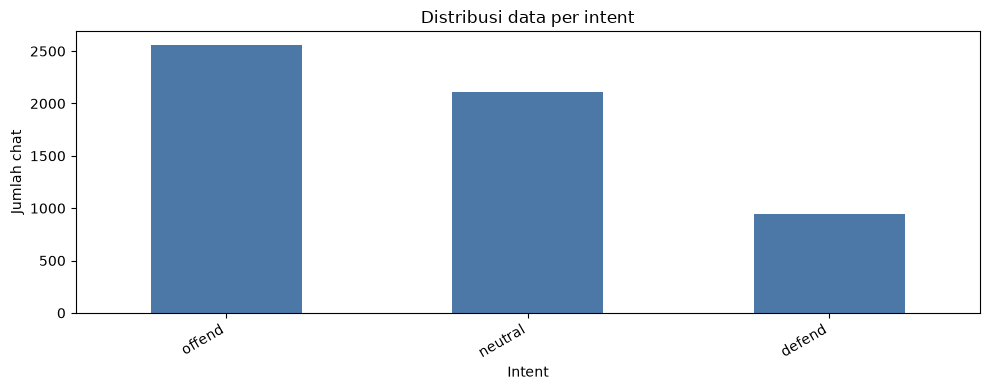

In [6]:
data_bersih, laporan_eda = run_eda()


## Split, Evaluasi, Penyimpanan Model, dan Prediksi


### Seed Eksperimen


Seed membantu mengulang pengacakan secara konsisten.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `RANDOM_STATE=42` | Menjadi acuan pengacakan split, CV, SVM, Optuna, dan IndoBERT. | 42 adalah angka pilihan, bukan tingkat akurasi. Menggantinya dapat mengubah pembagian dan hasil; seed tetap bukan jaminan hasil identik pada semua perangkat. |


In [7]:
# Menetapkan seed untuk pembagian data, cross-validation, dan training yang konsisten.
RANDOM_STATE = 42

# Folder penyimpanan model hasil training.
MODEL_DIR = Path("models/notebook_standalone")


### Pembagian Data Latih dan Test


Train untuk belajar; test untuk evaluasi setelah training atau pencarian parameter selesai.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `test_size=0.2` | Menentukan porsi test. | 20% test dan sekitar 80% train. Test lebih besar menyisakan lebih sedikit data belajar. |
| `x_train / x_test` | Teks masukan. | x adalah chat; train untuk belajar, test untuk evaluasi akhir. |
| `y_train / y_test` | Label jawaban benar. | y berisi intent yang seharusnya diprediksi dari chat pada x. |
| `stratify` | Menjaga proporsi intent di tiap bagian. | Menggunakan label_intent agar pembagian tidak menghilangkan keseimbangan kelas secara sembarang. |


In [8]:
# Membagi data bersih menjadi data latih dan uji dengan proporsi intent tetap terwakili.
def _split_dataset(dataset_path, test_size = 0.2):
    data, data_report = load_clean_nlu_dataset(dataset_path)
    x_train, x_test, y_train, y_test = train_test_split(
        data["teks_chat"],
        data["label_intent"],
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=data["label_intent"],
    )
    return x_train, x_test, y_train, y_test, data_report


### Arti Metrik Evaluasi


Prediksi test dibandingkan dengan label asli. Skala metrik 0?1; umumnya makin tinggi makin baik.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `y_pred / y_test` | Prediksi dan jawaban asli. | Prediksi defend cocok dengan label defend berarti benar. |
| `accuracy` | Proporsi semua prediksi benar. | 0.90 berarti 90% chat test benar; bisa tampak tinggi bila kelas mayoritas mendominasi. |
| `precision` | Ketepatan prediksi suatu kelas. | Dari semua yang diprediksi defend, berapa bagian benar-benar defend? |
| `recall` | Kemampuan menemukan anggota kelas. | Dari semua defend sebenarnya, berapa bagian yang dikenali sebagai defend? |
| `F1 / macro-F1` | Menggabungkan precision dan recall. | F1 adalah rata-rata harmonik keduanya; macro-F1 merata-ratakan F1 tiap kelas dengan bobot sama. |
| `weighted-F1 / support` | Memperhitungkan banyaknya contoh kelas. | support adalah jumlah contoh asli; weighted-F1 memberi bobot lebih besar pada kelas dengan support besar. |
| `zero_division=0` | Menangani pembagi nol dalam metrik. | Metrik yang tidak dapat dihitung diberi 0, misalnya tidak ada prediksi untuk suatu kelas. |


In [9]:
# -----------------------------------------------------------------------------
# Evaluasi, penyimpanan model, dan prediksi model klasik.
# -----------------------------------------------------------------------------

# Menghitung metrik data test; tampilannya diatur pada cell training dan laporan.
def _evaluate(model, x_test, y_test, title):

    # Memprediksi data uji lalu menghitung ukuran ketepatan model.
    y_pred = model.predict(x_test)
    metrics = {
        "accuracy": round(float(accuracy_score(y_test, y_pred)), 4),
        "f1_macro": round(float(f1_score(y_test, y_pred, average="macro", zero_division=0)), 4),
        "f1_weighted": round(float(f1_score(y_test, y_pred, average="weighted", zero_division=0)), 4),
        "classification_report": classification_report(y_test, y_pred, zero_division=0),
    }

    return metrics


### Menyimpan Model Terlatih


Hasil belajar disimpan agar prediksi tidak perlu melatih ulang.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `model / joblib.dump` | Menyimpan pipeline ke file .pkl. | Pipeline memuat TF-IDF dan classifier, termasuk kosakata serta bobot terlatih; keduanya digunakan bersama saat prediksi. |


In [10]:
# Menyimpan model klasik ke file agar dapat dipakai lagi untuk prediksi.
def _save_sklearn_model(model, model_dir, filename):
    output_dir = Path(model_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    model_path = output_dir / filename
    joblib.dump(model, model_path)
    return model_path


### Prediksi SVM dan Naive Bayes


Satu chat dimasukkan ke model tersimpan untuk mendapatkan intent dan confidence.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `text / predicted` | Chat input dan label hasil prediksi. | Hasilnya kelas yang sudah dipelajari, misalnya defend, offend, atau neutral. |
| `predict_proba / confidence` | Probabilitas tiap kelas dan nilai tertingginya. | Probabilitas tertinggi ? 100 menjadi persen; confidence 90% bukan jaminan prediksi benar. |
| `decision_function` | Alternatif bila model hanya memberi skor keputusan. | Skor diubah menjadi distribusi mirip probabilitas; ini tidak otomatis terkalibrasi. |
| `NaN` | Menandai confidence tidak tersedia. | Dipakai jika model tidak menyediakan probabilitas atau skor keputusan; bukan confidence 0%. |


In [11]:
# Memuat model klasik pilihan, lalu mengembalikan prediksi intent dan confidence untuk satu chat.
def predict_intent(text, model_dir, filename):
    """Prediksi label dan confidence dari nama file model yang disebutkan eksplisit."""

    # Memastikan file model tersedia sebelum dimuat.

    model_path = Path(model_dir) / filename
    if not model_path.is_file():
        raise FileNotFoundError(f"File model tidak ditemukan: {model_path}. Periksa nama file dan folder model yang dipakai.")

    # Memuat model tersimpan dan memprediksi label chat.
    model = joblib.load(model_path)
    predicted = str(model.predict([str(text)])[0])

    # Menghitung confidence dari probabilitas jika tersedia, atau dari skor keputusan; jika keduanya tidak ada, memakai NaN.
    if hasattr(model, "predict_proba"):
        confidence = float(np.max(model.predict_proba([str(text)])[0]) * 100)
    elif hasattr(model, "decision_function"):
        scores = np.asarray(model.decision_function([str(text)]), dtype=float).reshape(1, -1)
        probabilities = np.exp(scores - scores.max(axis=1, keepdims=True))
        probabilities /= probabilities.sum(axis=1, keepdims=True)
        confidence = float(probabilities.max() * 100)
    else:
        confidence = float("nan")

    return predicted, round(confidence, 2)


### Format Hasil Model


Hasil dikemas agar berbagai model dapat dibaca oleh laporan yang sama.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `model / model_path` | Objek terlatih dan lokasi file. | model untuk pemakaian di memori; model_path untuk memuat model tersimpan. |
| `metrics / data_report` | Metrik model dan catatan dataset. | metrics berisi skor test; data_report berisi kualitas data, bukan kemampuan model. |
| `extra` | Informasi tambahan hasil eksperimen. | Misalnya parameter terbaik, skor CV, tokenizer, atau riwayat IndoBERT. |


In [12]:
# Mengemas model, metrik, laporan data, dan lokasi file dalam format hasil yang seragam.
def _result(
    model,
    metrics,
    report,
    model_path,
    **extra,
):
    """Samakan format hasil agar notebook dapat membandingkan semua model."""
    return {
        "model": model,
        "metrics": metrics,
        "data_report": report,
        "model_path": str(model_path),
        **extra,
    }


## Persiapan Model dan Tuning


Pengaturan CV, fitur TF-IDF, pilihan parameter, Grid Search, dan Optuna yang dipakai bersama oleh SVM dan Naive Bayes.


In [13]:
#  settinggan untuk biar training cpu/gpu gitu ga ngaruh ke ini skripsi-----------------------------------------------------------------------------

# Model klasik dijalankan pada CPU.
CLASSICAL_DEVICE = "cpu"

# Gunakan seluruh core CPU yang tersedia untuk CV paralel.
CV_N_JOBS = -1

### Pengaturan CV dan Batas Optuna


CV menilai kandidat pada data train; Optuna berhenti sesuai batas trial, waktu, atau stagnasi.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `CV_FOLDS=5` | Jumlah pembagian cross-validation. | Belajar pada 4 bagian, dinilai pada 1 bagian, bergantian 5 kali. Makin banyak fold, makin banyak pekerjaan training. |
| `OPTUNA_MIN_TRIALS=100` | Fase awal sebelum menghitung stagnasi. | Mulai menghitung stagnasi setelah 100 trial COMPLETE; error atau timeout masih bisa menghentikan lebih awal. |
| `OPTUNA_PATIENCE=30` | Toleransi trial stagnan setelah fase awal. | Berhenti setelah 30 trial COMPLETE tanpa peningkatan cukup. Lebih besar memberi pencarian lebih lama. |
| `OPTUNA_MIN_DELTA=0.001` | Batas kenaikan skor yang dianggap cukup. | 0.850 ke 0.851 naik 0.001 atau 0.1 poin persentase. Lebih kecil membuat peningkatan kecil lebih mudah diterima. |
| `OPTUNA_MAX_TRIALS=500` | Batas jumlah percobaan. | Maksimal 500 trial, bisa berhenti lebih awal; tidak harus 500 kombinasi unik. |
| `OPTUNA_TIMEOUT=None` | Batas waktu pencarian. | None berarti tanpa batas waktu; angka berarti detik dan dapat menghentikan sebelum minimum trial tercapai. |


In [14]:
# Jumlah fold untuk cross-validation saat tuning. artinya Dipakai saat Grid Search dan Optuna untuk menilai kandidat parameter,ata training dibagi menjadi 5 bagian.
# Setiap kandidat dilatih memakai 4 bagian dan dinilai pada 1 bagian, bergantian sebanyak 5 kali. Rata-rata macro-F1 dipakai untuk memilih parameter terbaik.
CV_FOLDS = 5


# Batas trial dan aturan berhenti Optuna saat skor tidak membaik.
OPTUNA_MIN_TRIALS = 100

# klo dia udh lewat min_trial kita set dia baca max 30 klo ga membaik tolak
OPTUNA_PATIENCE = 30

# batas minila peningkatan skot macro-F1 yang dianggap membaik. Jika perbaikan kurang dari ini, Optuna akan menghentikan pencarian parameter.
OPTUNA_MIN_DELTA = 0.001

# Batas maksimal trial Optuna. Jika diisi, Optuna akan berhenti setelah mencapai jumlah ini meski skor masih membaik.
OPTUNA_MAX_TRIALS = 500

OPTUNA_TIMEOUT = None  # Bila diisi, timeout boleh menghentikan sebelum 100 trial.


### TF-IDF Baseline


Baseline adalah pembanding dengan parameter tetap sebelum tuning.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `ngram_range=(1,2)` | Mengambil kata tunggal dan pasangan dua kata. | Contoh bukan dan bukan hitman dipakai bersama sebagai fitur. |
| `min_df=1 / max_df=0.98` | Menyaring fitur menurut jumlah chat. | Boleh muncul hanya pada 1 chat; dibuang jika muncul pada lebih dari 98% chat training. |
| `sublinear_tf=True` | Mengurangi dominasi fitur berulang. | Frekuensi positif menjadi 1 + log(frekuensi), sehingga pengaruh pengulangan bertambah lebih lambat. |
| `strip_accents="unicode"` | Menyeragamkan karakter beraksen. | Variasi aksen huruf dinormalisasi agar tidak selalu menjadi fitur berbeda. |


In [15]:
# Membuat pengubah teks menjadi fitur TF-IDF untuk model baseline.
def _baseline_tfidf():
    """Fitur baseline tetap; kalibrasi SVM memakai pipeline lengkap."""
    return TfidfVectorizer(
        ngram_range=(1, 2), min_df=1, max_df=0.98,
        sublinear_tf=True, strip_accents="unicode",
    )


### TF-IDF dan Pilihan Parameter Tuning


**TF-IDF mengubah chat menjadi angka** agar SVM dan Naive Bayes bisa mengenali intent `offend`, `defend`, atau `neutral`. Angka tersebut mewakili bobot kata atau potongan karakter: seberapa sering muncul dalam satu chat, serta seberapa umum di kumpulan chat training.

Daftar `[ ... ]` berisi **pilihan yang dicoba saat tuning**, bukan semuanya dipakai sekaligus. `common` berisi pilihan bersama; perulangan `for analyzer, ngrams` memasangkan jenis fitur dengan panjang rangkaiannya. Awalan `tfidf__`, `svm__`, dan `nb__` menunjukkan bagian model yang diatur.

| Nama parameter | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `tfidf__min_df` | Membuang fitur yang terlalu jarang muncul. | `1`: cukup ada di 1 chat; `2`: harus ada di minimal 2 chat. Makin besar, makin banyak fitur langka dibuang. Ini jumlah **chat**, bukan pengulangan kata dalam satu chat. |
| `tfidf__max_df` | Membuang fitur yang terlalu umum. | `0.95`: buang fitur yang muncul di lebih dari 95% chat; `1.0`: boleh muncul di semua chat. Makin kecil, makin ketat menyaring fitur umum. |
| `tfidf__sublinear_tf` | Mengatur pengaruh kata/fitur yang berulang dalam satu chat. | `True`: gunakan `1 + log(jumlah kemunculan)` agar pengulangan tidak terlalu dominan. `False`: gunakan jumlah asli, misalnya muncul 5 kali berarti TF awal = 5. |
| `tfidf__analyzer` / `analyzer` | Memilih bentuk fitur teks. | `word`: kata atau rangkaian kata. `char_wb`: potongan karakter dalam batas kata, dengan spasi di tepinya; dapat membantu mengenali variasi ejaan. |
| `tfidf__ngram_range` / `ngrams` untuk `word` | Memilih panjang rangkaian kata. | `(1,1)`: kata tunggal; `(1,2)`: kata tunggal + pasangan 2 kata; `(1,3)`: tambah rangkaian 3 kata. Contoh: **aku**, **bukan hitman**, **aku bukan hitman**. Batas atas lebih besar menangkap konteks lebih panjang, tetapi bisa menambah jumlah fitur. SVM mencoba ketiganya; NB mencoba dua pertama. |
| `tfidf__ngram_range` / `ngrams` untuk `char_wb` | Memilih panjang potongan karakter untuk SVM. | `(3,5)`: semua panjang 3 sampai 5 karakter; `(3,6)`: 3 sampai 6 karakter. Contoh dari **hitman**: **hit**, **hitm**, **hitma**. Angkanya menghitung karakter, bukan kata; batas lebih besar menambah potongan yang lebih panjang. |
| `svm__C` | Mengatur seberapa kuat SVM mengejar kecocokan dengan data latih. | Mengambil pilihan `SVM_C_VALUES` (0.25?8.0). C kecil: bobot lebih dibatasi, tetapi pola penting bisa terlewat. C besar: kesalahan training lebih ditekan, tetapi pola kebetulan bisa ikut dipelajari. |
| `svm__class_weight` | Mengatur bobot kesalahan tiap intent. | `None`: semua kelas berbobot sama. `balanced`: kelas yang datanya lebih sedikit mendapat bobot lebih besar; jumlah datanya tidak berubah. |
| `tfidf__use_idf` | Mengatur apakah fitur umum diberi bobot lebih rendah dibanding fitur yang jarang tersebar. | `True`: gunakan IDF, yaitu bobot berdasarkan penyebaran fitur antar-chat. `False`: tidak gunakan IDF. Pilihan ini dicoba pada tuning NB. |
| `tfidf__norm` | Menyamakan skala vektor fitur agar panjang chat tidak langsung mendominasi. | `l1`: jumlah bobot absolut dibuat 1. `l2`: akar jumlah kuadrat bobot dibuat 1. `None`: tidak dinormalisasi. Ini pilihan cara penskalaan, bukan urutan kecil?besar. |
| `nb__alpha` | Menambahkan bobot kecil pada fitur agar fitur yang belum muncul di suatu kelas tidak berpeluang nol (**smoothing**). | Mengambil pilihan `NB_ALPHA_VALUES` (0.01?2.0). Kecil: lebih mengikuti data latih. Besar: peluang fitur dalam kelas lebih merata, tetapi perbedaan fitur penting bisa melemah. |
| `nb__fit_prior` | Mengatur peluang awal setiap intent sebelum melihat isi chat. | `True`: mengikuti proporsi kelas pada data latih. `False`: semua intent memiliki peluang awal yang sama. |

**Nilai lebih besar tidak otomatis lebih bagus.** Kandidat dipilih berdasarkan rata-rata macro-F1 cross-validation, bukan skor data test.


In [16]:
# Menyediakan pilihan parameter SVM atau Naive Bayes untuk Grid Search dan Optuna.
def _classical_search_spaces(model_kind):
    """Kembalikan grid baru agar mutasi satu eksperimen tidak mengubah lainnya."""
    common = {
        "tfidf__min_df": [1, 2],
        "tfidf__max_df": [0.95, 1.0],
        "tfidf__sublinear_tf": [True, False],
    }

    # Memilih ruang pencarian SVM, termasuk fitur kata atau karakter, nilai C, dan bobot kelas.
    if model_kind == "svm":
        return [
            {
                **deepcopy(common),
                "tfidf__analyzer": [analyzer],
                "tfidf__ngram_range": ngrams,
                "svm__C": list(SVM_C_VALUES),
                "svm__class_weight": [None, "balanced"],
            }
            for analyzer, ngrams in [
                ("word", [(1, 1), (1, 2), (1, 3)]),
                ("char_wb", [(3, 5), (3, 6)]),
            ]
        ]

    # Memilih ruang pencarian Naive Bayes, termasuk fitur kata, alpha, dan prior kelas.
    if model_kind == "nb":
        return [{
            **deepcopy(common),
            "tfidf__analyzer": ["word"],
            "tfidf__ngram_range": [(1, 1), (1, 2)],
            "tfidf__use_idf": [True, False],
            "tfidf__norm": ["l2", "l1", None],
            "nb__alpha": list(NB_ALPHA_VALUES),
            "nb__fit_prior": [True, False],
        }]

    raise ValueError("model_kind harus 'svm' atau 'nb'.")


### Fold Penilaian dan Kalibrasi


Fold dibuat sekali agar semua kandidat dinilai pada pembagian yang sama.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `cv_folds / folds` | Jumlah bagian dan indeks train/validation tiap fold. | Default 5; semuanya berasal dari data train, bukan data test. |
| `shuffle / RANDOM_STATE` | Mengacak pembagian secara konsisten. | StratifiedKFold menjaga proporsi kelas pada tiap bagian. |
| `calibration_folds` | Pembagian tambahan untuk confidence SVM. | 3 untuk SVM, dilakukan di dalam data train fold utama. 0 untuk NB berarti tanpa kalibrasi tambahan. |


In [17]:
# Menyiapkan fold CV yang sama untuk semua kandidat dan 3 fold kalibrasi khusus SVM.
def _classical_cv(y_train, model_kind, cv_folds):
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    folds = list(cv.split(np.zeros(len(y_train)), y_train))
    calibration_folds = 3 if model_kind == "svm" else 0
    return folds, calibration_folds


### Proses Grid Search


Mencoba semua kombinasi lalu melatih ulang pemenang pada seluruh train.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `grid / ParameterGrid` | Daftar kombinasi parameter. | Sekarang 720 kandidat SVM dan 1.920 NB; tiap kandidat menjalani semua fold. |
| `scoring / refit="f1_macro"` | Menilai kandidat dan menentukan pemenang. | Accuracy dan macro-F1 CV dihitung; pemilihan hanya berdasarkan rata-rata macro-F1 CV tertinggi. |
| `total_fits` | Jumlah pekerjaan CV. | Kandidat ? fold: 3.600 fit SVM dan 9.600 fit NB pada 5 fold; belum termasuk refit final dan kalibrasi internal. |
| `best_params_ / best_estimator_` | Konfigurasi terbaik dan model hasil refit. | Model ini baru dinilai pada test setelah pencarian selesai. |
| `cv_std` | Variasi F1 antar-fold. | Lebih kecil berarti skor lebih seragam; bukan jaminan accuracy tinggi atau interval kepastian. |
| `Progress CV` | Skor kandidat terbaik yang semua fold-nya selesai. | Accuracy yang terlihat milik kandidat terpilih berdasarkan macro-F1; sebelum selesai, metrik masih menunggu. |


In [18]:
# Mencoba semua kombinasi parameter dengan Grid Search, lalu mengevaluasi dan menyimpan model terbaik.
def _train_classical_grid(dataset_path, model_dir, filename, model_kind, cv_folds, n_jobs):
    """Coba seluruh grid pada train CV, refit pemenang, kemudian evaluasi test."""

    # Menyiapkan data, fold, pilihan parameter, dan folder hasil Grid Search.
    x_train, x_test, y_train, y_test, report = _split_dataset(dataset_path)
    folds, calibration_folds = _classical_cv(y_train, model_kind, cv_folds)
    spaces = _classical_search_spaces(model_kind)
    prefix = "estimator__" if model_kind == "svm" else ""
    grid = [{prefix + key: values for key, values in space.items()} for space in spaces]

    # Membuat pipeline di tempat kandidat dilatih agar alurnya mudah ditelusuri.
    if model_kind == "svm":
        model = _calibrated_linear_svm(1.0, None, calibration_folds)
    else:
        model = Pipeline([
            ("tfidf", TfidfVectorizer(strip_accents="unicode")),
            ("nb", MultinomialNB()),
        ])

    output_root = Path(model_dir) / "grid_results"
    output_root.mkdir(parents=True, exist_ok=True)
    run_dir = Path(tempfile.mkdtemp(prefix=f"{model_kind}_", dir=output_root))

    # Mencoba seluruh kombinasi dengan macro-F1 CV sebagai penentu model terbaik.
    search = GridSearchCV(
        model, grid, scoring={"accuracy": "accuracy", "f1_macro": "f1_macro"}, cv=folds, n_jobs=n_jobs,
        refit="f1_macro", verbose=0, error_score="raise", return_train_score=False,
    )
    total_fits = len(ParameterGrid(grid)) * len(folds)

    # Hasil fold diambil berurutan dari pekerjaan paralel; urutan kandidat dan jumlah worker tetap sama.
    class ProgressParallel(sklearn_search.Parallel):
        def __init__(self, *args, **kwargs):
            super().__init__(*args, return_as="generator", **kwargs)

        def __call__(self, tasks):
            results = []
            best_f1, best_accuracy = None, None
            for result in super().__call__(tasks):
                results.append(result)
                completed = len(results)
                if completed % len(folds) == 0:
                    candidate = results[-len(folds):]
                    candidate_f1 = float(np.mean([r["test_scores"]["f1_macro"] for r in candidate]))
                    if best_f1 is None or candidate_f1 > best_f1:
                        best_f1 = candidate_f1
                        best_accuracy = float(np.mean([r["test_scores"]["accuracy"] for r in candidate]))
                # Postfix menampilkan skor CV kandidat terbaik yang seluruh fold-nya selesai.
                if best_f1 is not None:
                    progress.set_postfix(
                        cv_accuracy=f"{best_accuracy:.4f}", cv_macro_f1=f"{best_f1:.4f}", refresh=False,
                    )
                progress.update(1)
                if completed == total_fits:
                    progress.set_description(f"Grid {model_kind.upper()} - refit terbaik")
            return results

    started = perf_counter()
    # tqdm memperbarui satu baris; adapter paralel hanya aktif selama GridSearchCV.fit().
    with tqdm(total=total_fits, desc=f"Grid {model_kind.upper()} - CV", unit="fit", dynamic_ncols=True) as progress:
        try:
            with patch.object(sklearn_search, "Parallel", ProgressParallel):
                search.fit(x_train, y_train)
        except BaseException:
            progress.set_description(f"Grid {model_kind.upper()} - terhenti")
            raise
        progress.set_description(f"Grid {model_kind.upper()} - selesai")
    search_seconds = perf_counter() - started

    # Menyimpan hasil setiap kandidat dan mengambil parameter serta variasi skor kandidat terbaik.
    search.cv_results_["mean_test_score"] = search.cv_results_["mean_test_f1_macro"]
    search.cv_results_["std_test_score"] = search.cv_results_["std_test_f1_macro"]
    search.cv_results_["rank_test_score"] = search.cv_results_["rank_test_f1_macro"]
    pd.DataFrame(search.cv_results_).to_csv(run_dir / "cv_results.csv", index=False)
    best = {key.removeprefix(prefix): value for key, value in search.best_params_.items()}
    cv_std = float(search.cv_results_["std_test_f1_macro"][search.best_index_])

    # Tidak ada perubahan struktur estimator setelah pemilihan kandidat.
    model = search.best_estimator_
    metrics = _evaluate(model, x_test, y_test, f"{model_kind.upper()} Grid Search")
    path = _save_sklearn_model(model, model_dir, filename)

    # Merangkum konfigurasi, durasi, dan hasil evaluasi untuk laporan eksperimen.
    summary = {
        "method": "Grid Search", "model_kind": model_kind, "seed": RANDOM_STATE,
        "candidate_count": len(search.cv_results_["params"]),
        "cv_folds": len(folds), "calibration_folds": calibration_folds or None,
        "selection_metric": "cv_f1_macro", "test_used_for_selection": False,
        "best_params": best, "cv_f1_macro": float(search.best_score_), "cv_std": cv_std,
        "search_and_refit_seconds": search_seconds,
        "metrics": metrics, "data_report": report, "model_path": str(path),
    }
    _save_search_report(run_dir, x_train, x_test, folds, summary)
    return _result(
        model, metrics, report, path, best_params=best,
        cv_f1_macro=round(float(search.best_score_), 4), cv_std=cv_std,
        run_dir=str(run_dir), training_summary=summary,
    )


### Penghentian Stagnasi Optuna


Stagnasi berarti belum ada kenaikan cukup terhadap skor acuan.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `completed / stale_trials` | Jumlah trial selesai dan trial stagnan. | Hanya trial COMPLETE dengan skor valid yang dihitung. |
| `reference_best / gain` | Skor acuan dan selisih skor terbaik terhadapnya. | Kenaikan kecil dapat menumpuk sampai mencapai min_delta. |
| `patience / min_delta` | Toleransi stagnasi dan ambang perbaikan. | Perbaikan cukup mereset penghitung menjadi 0; mencapai patience menghentikan study. |
| `study.best_trial` | Trial pemenang sebenarnya. | Tetap mengambil skor tertinggi, termasuk peningkatan yang lebih kecil dari min_delta. |


In [19]:
class OptunaStagnationStopper:
    """Hentikan study setelah fase awal dan beberapa trial COMPLETE stagnan.

    Setelah min_trials selesai, skor terbaik menjadi acuan. Peningkatan kecil
    dapat terakumulasi terhadap acuan tersebut. Patience baru dihitung setelah
    fase awal; FAIL/PRUNED tidak dihitung. Pemilihan model tetap memakai best
    trial sebenarnya, bukan skor acuan penghentian.
    """

    # Menyiapkan batas trial awal, toleransi stagnasi, dan penghitung untuk penghentian Optuna.
    def __init__(self, min_trials=100, patience=30, min_delta=0.001):

        # Menginisialisasi pengaturan dan penghitung sebelum pencarian dimulai.
        self.min_trials = min_trials
        self.patience = patience
        self.min_delta = min_delta
        self.completed = 0
        self.stale_trials = 0
        self.reference_best = None
        self.stop_reason = None

    # Memperbarui perkembangan skor setiap trial dan menghentikan Optuna bila terlalu lama tidak meningkat.
    def __call__(self, study, trial):

        # Mengabaikan trial yang belum selesai atau tidak menghasilkan skor yang valid.
        if trial.state.name != "COMPLETE" or trial.value is None:
            return

        if not math.isfinite(trial.value):
            return

        # Menghitung trial selesai dan mengambil skor terbaik sejauh ini.
        self.completed += 1
        best = float(study.best_value)

        # Selama fase awal, memperbarui skor acuan tanpa menghitung stagnasi.
        if self.completed <= self.min_trials:
            self.reference_best = best
            self.stale_trials = 0
            phase = f"fase awal {self.completed}/{self.min_trials}"
        else:
            gain = best - self.reference_best

            # Mereset penghitung jika peningkatan cukup besar; selain itu menambah jumlah trial stagnan.
            if gain > 0 and gain + 1e-12 >= self.min_delta:
                self.reference_best = best
                self.stale_trials = 0
            else:
                self.stale_trials += 1
            phase = f"stagnasi {self.stale_trials}/{self.patience}"

            # Menghentikan pencarian ketika jumlah trial stagnan mencapai patience.
            if self.stale_trials >= self.patience:
                self.stop_reason = "stagnation"
                study.stop()

        # Mencatat status penghentian; progress ditampilkan oleh Optuna.
        study.set_user_attr("stopping_state", self.state())

    # Mengembalikan jumlah trial dan status penghentian untuk dicatat dalam laporan.
    def state(self):
        return {
            "completed": self.completed, "stale_trials": self.stale_trials,
            "reference_best": self.reference_best, "stop_reason": self.stop_reason,
        }


### Pemilihan Parameter Optuna


Satu trial berarti satu kombinasi dari daftar pilihan yang tersedia.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `suggest_categorical` | Memilih satu nilai yang akan dicoba. | Misalnya C dipilih dari SVM_C_VALUES, bukan sembarang angka di antaranya. |
| `analyzer / space` | Memasangkan jenis fitur dan ruang pencariannya. | SVM memilih kata/karakter; NB memakai kata. |
| `encoded / ngram_range` | Menyimpan pasangan n-gram sebagai kategori. | Teks 1,2 dikembalikan menjadi tuple (1,2); hanya format penyimpanan yang berubah. |


In [20]:
# Meminta Optuna memilih satu kombinasi parameter dari pilihan yang tersedia.
def _suggest_optuna_params(trial, model_kind):
    """TPE memilih nilai diskret yang sama persis dengan Grid Search."""
    spaces = _classical_search_spaces(model_kind)

    # Memilih jenis fitur SVM; Naive Bayes memakai fitur kata.
    if model_kind == "svm":
        analyzers = [space["tfidf__analyzer"][0] for space in spaces]
        analyzer = trial.suggest_categorical("analyzer", analyzers)
        space = next(s for s in spaces if s["tfidf__analyzer"] == [analyzer])
    else:
        analyzer, space = "word", spaces[0]

    params = {"tfidf__analyzer": analyzer}

    # Optuna menyimpan kategori primitif; tuple n-gram dikodekan sebagai string.
    # Nama n-gram berbeda per analyzer agar distribution tidak berubah antar-trial.
    choices = [f"{low},{high}" for low, high in space["tfidf__ngram_range"]]
    encoded = trial.suggest_categorical(f"{analyzer}_ngram_range", choices)
    params["tfidf__ngram_range"] = tuple(map(int, encoded.split(",")))

    # Memilih nilai untuk parameter lain yang belum ditentukan.
    for key, choices in space.items():
        if key not in {"tfidf__analyzer", "tfidf__ngram_range"}:
            params[key] = trial.suggest_categorical(key, choices)

    return params


### Proses Tuning Optuna


TPE memakai riwayat percobaan untuk membantu memilih kandidat berikutnya.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `study / sampler` | Kumpulan trial dan metode pemilihan parameter. | direction=maximize mencari skor terbesar; TPESampler memakai seed eksperimen. |
| `objective / scores` | Menilai satu kandidat pada semua fold. | Mengembalikan rata-rata macro-F1 sebagai skor yang dioptimalkan. |
| `cv_accuracy / cv_std` | Metrik tambahan untuk laporan. | Accuracy tidak menentukan pemenang; std mengukur variasi F1 antar-fold. |
| `NopPruner` | Menyelesaikan semua fold tiap kandidat. | Tidak memangkas trial di tengah; penghentian stagnasi berlaku pada pencarian keseluruhan. |
| `best / model.fit` | Melatih ulang kandidat terbaik. | Seluruh data train dipakai untuk refit, baru dievaluasi pada test. |
| `stop_reason` | Alasan berhenti. | stagnation: tidak cukup membaik; max_trials: batas trial; timeout: batas waktu. |


In [21]:
# Mencari parameter dengan Optuna, melatih ulang kandidat terbaik, lalu mengevaluasi dan menyimpan hasil.
def _train_classical_optuna(
    dataset_path, model_dir, filename, *, model_kind, n_trials, cv_folds,
    timeout, n_jobs, min_trials, patience, min_delta,
):
    """TPE pada train CV; berhenti adaptif, refit best, lalu evaluasi test."""

    # Menyiapkan penghentian otomatis saat skor Optuna tidak membaik.
    stopper = OptunaStagnationStopper(min_trials, patience, min_delta)

    # Menyiapkan pembagian data dan folder penyimpanan hasil Optuna.
    x_train, x_test, y_train, y_test, report = _split_dataset(dataset_path)
    folds, calibration_folds = _classical_cv(y_train, model_kind, cv_folds)
    output_root = Path(model_dir) / "optuna_results"
    output_root.mkdir(parents=True, exist_ok=True)
    run_dir = Path(tempfile.mkdtemp(prefix=f"{model_kind}_", dir=output_root))

    # Membuat pencarian TPE yang memaksimalkan macro-F1 tanpa memangkas trial di tengah evaluasi.
    study = optuna.create_study(
        direction="maximize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        pruner=optuna.pruners.NopPruner(),  # Satu kandidat dinilai dengan semua fold.
        study_name=f"{model_kind}_macro_f1",
    )

    # Mengukur rata-rata macro-F1 cross-validation untuk satu kombinasi parameter yang dicoba Optuna.
    def objective(trial):
        params = _suggest_optuna_params(trial, model_kind)

        # Catat konfigurasi juga bila training kandidat gagal.
        trial.set_user_attr("pipeline_params", params)

        # Membuat pipeline di tempat kandidat dilatih agar alurnya mudah ditelusuri.
        if model_kind == "svm":
            model = _calibrated_linear_svm(1.0, None, calibration_folds)
            model.set_params(**{f"estimator__{key}": value for key, value in params.items()})
        else:
            model = Pipeline([
                ("tfidf", TfidfVectorizer(strip_accents="unicode")),
                ("nb", MultinomialNB()),
            ]).set_params(**params)

        # Menilai kandidat pada seluruh fold dan menolak skor yang tidak valid.
        cv_results = cross_validate(
            model, x_train, y_train, cv=folds,
            scoring={"accuracy": "accuracy", "f1_macro": "f1_macro"},
            n_jobs=n_jobs, error_score="raise",
        )
        scores = cv_results["test_f1_macro"]
        trial.set_user_attr("cv_accuracy", float(cv_results["test_accuracy"].mean()))
        if not np.all(np.isfinite(scores)):
            raise ValueError("Skor CV tidak finite; periksa dataset dan kandidat.")

        trial.set_user_attr("fold_scores", scores.tolist())
        trial.set_user_attr("cv_std", float(scores.std()))
        return float(scores.mean())

    # Memeriksa kondisi berhenti dan menyimpan riwayat setelah satu trial Optuna selesai.
    def after_trial(study, trial):
        stopper(study, trial)
        if study.best_trials:
            best_trial = study.best_trial
            progress.set_postfix(
                cv_accuracy=f"{best_trial.user_attrs['cv_accuracy']:.4f}",
                cv_macro_f1=f"{best_trial.value:.4f}",
                stagnasi=f"{stopper.stale_trials}/{patience}", refresh=False,
            )
        progress.update(1)
        study.trials_dataframe().to_csv(run_dir / "trials.csv", index=False)

    with tqdm(total=n_trials, desc=f"Optuna {model_kind.upper()}", unit="trial", dynamic_ncols=True) as progress:
        started = perf_counter()

        # Trial berurutan untuk reproducibility; hanya fold CV yang paralel.
        # Kesalahan training tidak disembunyikan. Riwayat tetap disimpan di finally.
        # Sembunyikan log INFO per trial; warning/error tetap terlihat dan progress bar tetap berjalan.
        previous_verbosity = optuna.logging.get_verbosity()
        optuna.logging.set_verbosity(optuna.logging.WARNING)
        try:
            study.optimize(
                objective, n_trials=n_trials, timeout=timeout,
                n_jobs=1, callbacks=[after_trial], show_progress_bar=False,
            )
        finally:
            optuna.logging.set_verbosity(previous_verbosity)
            study.trials_dataframe().to_csv(run_dir / "trials.csv", index=False)

        # Mencatat durasi, alasan berhenti, dan parameter kandidat dengan skor terbaik.
        search_seconds = perf_counter() - started
        reason = stopper.stop_reason or (
            "max_trials" if len(study.trials) >= n_trials else "timeout"
        )
        progress.set_description(f"Optuna {model_kind.upper()} - refit ({reason})")
        best = dict(study.best_trial.user_attrs["pipeline_params"])
        best["tfidf__ngram_range"] = tuple(best["tfidf__ngram_range"])

        # Best trial tetap dipilih, termasuk peningkatan terakhir yang < min_delta.
        # Membuat pipeline di tempat kandidat dilatih agar alurnya mudah ditelusuri.
        if model_kind == "svm":
            model = _calibrated_linear_svm(1.0, None, calibration_folds)
            model.set_params(**{f"estimator__{key}": value for key, value in best.items()})
        else:
            model = Pipeline([
                ("tfidf", TfidfVectorizer(strip_accents="unicode")),
                ("nb", MultinomialNB()),
            ]).set_params(**best)

        model.fit(x_train, y_train)
        progress.set_description(f"Optuna {model_kind.upper()} - selesai ({reason})")
    metrics = _evaluate(model, x_test, y_test, f"{model_kind.upper()} Optuna")
    path = _save_sklearn_model(model, model_dir, filename)

    # Merangkum jumlah trial, parameter, skor, dan status penghentian untuk laporan.
    summary = {
        "method": "Optuna TPE", "search_space": "same_discrete_grid",
        "model_kind": model_kind, "seed": RANDOM_STATE,
        "optuna_version": optuna.__version__,
        "max_trials": n_trials, "min_trials": min_trials,
        "patience": patience, "min_delta": min_delta,
        "n_trials_attempted": len(study.trials),
        "n_trials_completed": stopper.completed,
        "unique_candidates": len({
            json.dumps(t.user_attrs.get("pipeline_params", {}), sort_keys=True)
            for t in study.trials if t.state.name == "COMPLETE"
        }),
        "stop_reason": reason, "stopping_state": stopper.state(),
        "timeout": timeout, "search_seconds": search_seconds,
        "cv_folds": len(folds), "calibration_folds": calibration_folds or None,
        "selection_metric": "cv_f1_macro", "test_used_for_selection": False,
        "best_trial": study.best_trial.number,
        "best_params": best, "cv_f1_macro": float(study.best_value),
        "cv_std": float(study.best_trial.user_attrs["cv_std"]),
        "metrics": metrics, "data_report": report, "model_path": str(path),
    }
    _save_search_report(run_dir, x_train, x_test, folds, summary)
    return _result(
        model, metrics, report, path, best_params=best,
        cv_f1_macro=round(float(study.best_value), 4), cv_std=summary["cv_std"],
        study=study, run_dir=str(run_dir), training_summary=summary,
    )


## Laporan dan Evaluasi Model


Contoh chat, penyimpanan laporan, dan tampilan hasil yang digunakan bersama. Eksekusi training ada di section masing-masing model.


### Contoh Chat untuk Pemeriksaan


Sepuluh contoh memperlihatkan perilaku model; terpisah dari evaluasi dataset test.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `HOSTAGE_TEST_CASES` | Pasangan label yang diharapkan dan teks chat. | Contoh (defend, Aku bukan Hitman) berarti prediksi yang diharapkan adalah defend. |
| `Benar dari 10` | Jumlah contoh yang diprediksi sesuai label. | 9/10 berarti 90% pada sepuluh chat tersebut; bukan pengganti accuracy seluruh test. |


In [57]:
# Contoh chat dan label yang diharapkan untuk evaluasi tambahan.
HOSTAGE_TEST_CASES = [
    ("offend", "B kena Gag Order ketika mulai ditanya alibinya, menurutku itu pola Hitman."),
    ("defend", "Aku bukan Hitman. Tuduhan itu tidak punya bukti dari chat publik."),
    ("defend", "Aku Spy dan semalam Guard Raka, jadi jangan curigai dia."),
    ("neutral", "Stalker, kamu Peek siapa semalam dan apa hasil yang kamu lihat?"),
    ("offend", "Jangan hanya fokus ke aku; cek D yang ceritanya berubah setiap ditanya."),
    ("offend", "Vote C saja, dia paling diuntungkan ketika seseorang mendadak diam."),
    ("defend", "Klaimku Civilian, jadi aku memang tidak memiliki aksi malam."),
    ("neutral", "Malam ini chat terkunci, kita lanjut diskusi setelah fase pagi."),
    ("offend", "A selalu menghindar saat kita tanya kenapa dia menuduh tanpa bukti."),
    ("defend", "aku diam aja dari awal bukan berarti aku pelakunya; aku masih bisa menjelaskan alibiku di fase siang."),
]


### Catatan Eksperimen Tersimpan


Catatan membantu memeriksa asal hasil tanpa mengubah training.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `summary` | Merekam parameter, skor, dan durasi. | Memisahkan konfigurasi terbaik, CV, dan metrik test. |
| `split_indices` | Merekam indeks train/test dan fold CV. | Indeks mengacu pada data setelah dibersihkan, bukan selalu nomor baris CSV mentah. |


In [23]:
# Menyimpan ringkasan eksperimen, versi library, dan indeks pembagian data untuk pemeriksaan ulang.
def _save_search_report(run_dir, x_train, x_test, folds, summary):
    """Simpan audit split dan metadata; indeks merujuk pada dataset bersih."""

    # Mencatat versi library dan menyimpan ringkasan pencarian ke JSON.
    summary["environment"] = {
        "python": platform.python_version(), "sklearn": sklearn.__version__,
        "numpy": np.__version__, "pandas": pd.__version__,
    }
    (run_dir / "summary.json").write_text(
        json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8",
    )

    # Menyimpan indeks train, test, dan fold CV agar pembagiannya bisa diperiksa ulang.
    split = {
        "train": x_train.index.tolist(), "test": x_test.index.tolist(),
        "cv": [
            {
                "train": x_train.iloc[a].index.tolist(),
                "validation": x_train.iloc[b].index.tolist(),
            }
            for a, b in folds
        ],
    }
    (run_dir / "split_indices.json").write_text(
        json.dumps(split, indent=2), encoding="utf-8",
    )


### Membaca Laporan Model


Laporan menggunakan hasil training yang sudah selesai, tanpa melatih ulang.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `result / metrics` | Mengambil model dan metrik. | Tabel utama menampilkan data test; skor CV disajikan terpisah. |
| `training_table / waktu_detik` | Ringkasan hasil dan durasi. | Durasi meliputi training/evaluasi/penyimpanan di fungsi training; bukan seluruh tampilan laporan setelahnya. |
| `best_params / alasan_berhenti` | Menjelaskan hasil pencarian. | Konfigurasi pemenang dan alasan pencarian selesai; bukan penentu benar/salah satu prediksi. |
| `chat_table` | Hasil prediksi contoh chat. | expected=label asli, predicted=hasil model, benar/Cocok=perbandingannya; confidence dalam persen. |


In [24]:
# Menampilkan format laporan yang sama untuk satu model, tanpa melatih ulang model tersebut.
def tampilkan_laporan_model(result, nama_model, waktu_detik, transformer=False):
    metrics = result["metrics"]
    summary = result.get("training_summary", {})
    row = {
        "model": nama_model,
        "accuracy_holdout": metrics["accuracy"],
        "macro_f1_holdout": metrics["f1_macro"],
        "weighted_f1_holdout": metrics["f1_weighted"],
        "waktu_detik": round(waktu_detik, 1),
        "status": "berhasil",
    }

    # Hasil tuning menambahkan skor CV dan catatan proses pencarian.
    if "cv_f1_macro" in result:
        row.update({
            "macro_f1_cv": result["cv_f1_macro"], "std_f1_cv": result["cv_std"],
            "jumlah_kandidat_trial": summary.get("candidate_count", summary.get("n_trials_attempted")),
            "alasan_berhenti": summary.get("stop_reason", "seluruh_grid_selesai"),
            "run_dir": result["run_dir"],
        })

    training_table = pd.DataFrame([row])
    print("RINGKASAN EVALUASI:")
    # Tabel utama hanya berisi metrik; rincian pencarian dan lokasi file dipisahkan.
    display(training_table[[
        "model", "accuracy_holdout", "macro_f1_holdout", "weighted_f1_holdout", "waktu_detik",
    ]].rename(columns={
        "model": "Model", "accuracy_holdout": "Test accuracy", "macro_f1_holdout": "Test macro-F1",
        "weighted_f1_holdout": "Test weighted-F1", "waktu_detik": "Durasi (detik)",
    }).style.format({
        "Test accuracy": "{:.4f}", "Test macro-F1": "{:.4f}",
        "Test weighted-F1": "{:.4f}", "Durasi (detik)": "{:.1f}",
    }).hide(axis="index"))

    if "cv_f1_macro" in result:
        print("HASIL PENCARIAN PARAMETER:")
        display(pd.DataFrame([{
            "Macro-F1 CV": result["cv_f1_macro"], "Std CV": result["cv_std"],
            "Kandidat / trial": row["jumlah_kandidat_trial"], "Alasan berhenti": row["alasan_berhenti"],
        }]).style.format({"Macro-F1 CV": "{:.4f}", "Std CV": "{:.4f}"}).hide(axis="index"))
        print("PARAMETER TERBAIK:")
        display(pd.DataFrame([
            {"Parameter": key, "Nilai": str(value)}
            for key, value in result["best_params"].items()
        ]).style.format(escape="html").hide(axis="index"))

    print(f"Model tersimpan: {result['model_path']}")
    print("LAPORAN PER INTENT:")
    print(metrics["classification_report"])

    # Contoh chat dinilai terpisah; tidak dipakai untuk memilih parameter model.
    chats = []
    for expected, chat in HOSTAGE_TEST_CASES:
        if transformer:
            predicted, confidence = predict_transformer_intent(chat, MODEL_DIR, device=TRANSFORMER_DEVICE)
        else:
            predicted, confidence = predict_intent(chat, MODEL_DIR, filename=Path(result["model_path"]).name)

        chats.append({
            "model": nama_model, "chat": chat, "expected": expected,
            "predicted": predicted, "confidence_persen": confidence,
            "benar": predicted == expected,
        })

    chat_table = pd.DataFrame(chats)
    print("HASIL 10 CHAT UJI (bukan data pemilihan model):")
    display(chat_table[["chat", "expected", "predicted", "confidence_persen", "benar"]].rename(columns={
        "chat": "Chat", "expected": "Label asli", "predicted": "Prediksi",
        "confidence_persen": "Confidence (%)", "benar": "Cocok",
    }).style.format({"Confidence (%)": "{:.2f}"}, escape="html").hide(axis="index").set_properties(
        subset=["Chat"], **{"white-space": "normal", "max-width": "450px"},
    ))
    display(chat_table.groupby("model")["benar"].agg(
        jumlah_benar="sum", jumlah_chat="count", akurasi="mean",
    ).reset_index())
    return training_table, chat_table


## SVM


Konfigurasi, kalibrasi, baseline, dan tuning khusus SVM. Fungsi training disiapkan dahulu; cell eksekusi dan laporan berada di akhir section.


### Parameter Khusus SVM


SVM belajar batas pemisah antar-intent. Regularisasi membatasi bobot agar tidak terlalu mengikuti pola kebetulan.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `SVM_C_VALUES` | Pilihan C untuk tuning. | 0.25?8.0 adalah nilai yang dicoba. Kecil: pembatasan lebih kuat, bisa melewatkan pola penting. Besar: lebih mengejar kecocokan training, bisa mengikuti pola kebetulan. |
| `SVM_MAX_ITER=10000` | Batas langkah solver memperbaiki bobot. | Maksimal 10.000 iterasi dan bisa selesai lebih cepat bila stabil; bukan epoch IndoBERT, jumlah chat, atau trial. |
| `C terbaik` | Memilih konfigurasi yang sesuai data. | Ditentukan dari macro-F1 CV; C terbesar tidak otomatis paling akurat. |


In [25]:
# Pilihan nilai C untuk tuning SVM; penjelasan ada di bawah.
SVM_C_VALUES = [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 4.0, 8.0]

# Batas maksimum iterasi solver LinearSVC untuk mencari solusi training.
SVM_MAX_ITER = 10000


### Pipeline dan Kalibrasi SVM


Pipeline menggabungkan TF-IDF dengan classifier. Kalibrasi memetakan skor SVM ke probabilitas untuk confidence.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `vectorizer / pipeline` | Mengubah chat menjadi fitur lalu melatih pemisah intent. | TF-IDF dipelajari pada bagian train tiap fold, agar kosakata/IDF validation tidak ikut dipelajari. |
| `c / class_weight` | Mengatur penalti kesalahan. | C mengatur regularisasi; balanced memberi bobot lebih besar pada kelas yang datanya sedikit. |
| `calibration_cv=3` | Jumlah fold untuk kalibrasi confidence. | 3 bagian di dalam data train; berbeda dari 5 fold penilaian tuning. |
| `method="sigmoid" / ensemble=True` | Mengubah skor menjadi probabilitas. | Probabilitas model-model dari fold kalibrasi dirata-ratakan saat prediksi; tetap bukan jaminan kebenaran. |


In [26]:
# Membuat pipeline TF-IDF dan SVM dengan kalibrasi agar menghasilkan probabilitas kelas.
def _calibrated_linear_svm(
    c,
    class_weight = "balanced",
    calibration_cv = 3,
    *,
    vectorizer = None,
):
    """Kalibrasi sigmoid atas seluruh pipeline, termasuk vocabulary dan IDF."""

    # Menggabungkan pengubahan teks ke TF-IDF dan classifier SVM dalam satu pipeline.
    pipeline = Pipeline([
        ("tfidf", vectorizer if vectorizer is not None else TfidfVectorizer(
            strip_accents="unicode",
        )),
        ("svm", LinearSVC(
            C=c, class_weight=class_weight,
            random_state=RANDOM_STATE, max_iter=SVM_MAX_ITER,
        )),
    ])

    # Mengkalibrasi skor SVM dengan metode sigmoid pada pembagian data terpisah.
    return CalibratedClassifierCV(
        estimator=pipeline,
        method="sigmoid",
        cv=StratifiedKFold(
            n_splits=calibration_cv, shuffle=True, random_state=RANDOM_STATE,
        ),
        ensemble=True,
        n_jobs=1,  # Paralel hanya di CV luar, bukan di kedua tingkat sekaligus.
    )


### Training SVM Baseline


Model pembanding dengan parameter tetap sebelum tuning.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `c=2.0 / calibration_cv=3` | Memakai C tetap dan kalibrasi 3 fold. | Bobot kelas balanced mengikuti default fungsi pembuat SVM. |
| `model.fit / metrics` | Belajar dari train lalu dinilai pada test. | TF-IDF baseline memakai unigram + bigram. Setelah dievaluasi, model disimpan. |


In [27]:
# Melatih SVM baseline, mengevaluasi data uji, lalu menyimpan modelnya.
def train_svm(dataset_path, model_dir, filename="intent_classifier_svm.pkl"):
    """Baseline SVM; kalibrasi ikut memisahkan TF-IDF pada fold internal."""

    # Menyiapkan data serta pipeline SVM sebelum pelatihan.
    x_train, x_test, y_train, y_test, report = _split_dataset(dataset_path)
    model = _calibrated_linear_svm(
        c=2.0, calibration_cv=3, vectorizer=_baseline_tfidf(),
    )

    # Melatih model, mengukur hasil pada data uji, lalu menyimpannya.
    model.fit(x_train, y_train)
    metrics = _evaluate(model, x_test, y_test, "SVM baseline")
    path = _save_sklearn_model(model, model_dir, filename)
    return _result(model, metrics, report, path)


### Training SVM dengan Grid Search


Fungsi ini memilih jenis model lalu meneruskan proses ke fungsi bersama Grid Search.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `model_kind` | Memastikan jenis classifier. | svm untuk SVM; nb untuk Naive Bayes. Masing-masing memakai pilihan parameternya sendiri. |
| `cv_folds / hasil` | Jumlah fold dan hasil pencarian. | Cell eksekusi memakai CV_FOLDS=5; hasil memuat parameter terbaik, skor CV, metrik test, dan model tersimpan. |


In [28]:
# Menjalankan pencarian parameter Grid Search khusus untuk SVM.
def train_svm_tuned(
    dataset_path, model_dir, filename="intent_classifier_svm_tuned.pkl",
    cv_folds=5, *, n_jobs=-1,
):
    """Grid Search SVM lengkap, termasuk kalibrasi pada setiap kandidat."""
    return _train_classical_grid(dataset_path, model_dir, filename, "svm", cv_folds, n_jobs)


### Training SVM dengan Optuna


Fungsi ini memilih jenis model lalu meneruskan proses ke fungsi bersama Optuna.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `model_kind` | Memastikan jenis classifier. | svm untuk SVM; nb untuk Naive Bayes. Masing-masing memakai pilihan parameternya sendiri. |
| `cv_folds / hasil` | Jumlah fold dan hasil pencarian. | Cell eksekusi memakai CV_FOLDS=5; hasil memuat parameter terbaik, skor CV, metrik test, dan model tersimpan. |


In [29]:
# Menjalankan pencarian parameter Optuna khusus untuk SVM.
def train_svm_optuna(
    dataset_path, model_dir, filename="intent_classifier_svm_optuna.pkl", *,
    n_trials=500, cv_folds=5, timeout=None, n_jobs=-1,
    min_trials=100, patience=30, min_delta=0.001,
):
    """SVM Optuna dengan estimator/fold/parameter sama dengan Grid Search."""
    return _train_classical_optuna(
        dataset_path, model_dir, filename, model_kind="svm", n_trials=n_trials,
        cv_folds=cv_folds, timeout=timeout, n_jobs=n_jobs,
        min_trials=min_trials, patience=patience, min_delta=min_delta,
    )


### Jalankan SVM baseline dan Laporan


Cell pertama melatih model; cell berikutnya menampilkan hasil melalui fungsi laporan bersama.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `svm_baseline` | Menyimpan hasil run ini. | Memuat metrik dan model terlatih. Mengulang cell training berarti melatih ulang, bukan hanya memperbarui tampilan. |
| `hasil_svm_baseline / chat_svm_baseline` | Tabel metrik dan prediksi contoh chat. | Cell laporan dapat dijalankan ulang tanpa training selama variabel hasil training masih ada. |
| `waktu_svm_baseline` | Durasi run dalam detik. | Meliputi training, evaluasi, dan penyimpanan pada fungsi training; bukan waktu memprediksi satu chat. |


In [30]:
# Baseline tidak menyediakan hitungan langkah fit; tampilkan status dan durasi tanpa persentase.
_started = perf_counter()
with tqdm(total=None, desc="SVM baseline - training", bar_format="{desc} [{elapsed}]", dynamic_ncols=True) as progress:
    svm_baseline = train_svm(DATASET_PATH, MODEL_DIR)
    progress.set_description("SVM baseline - selesai")
waktu_svm_baseline = perf_counter() - _started

# Ringkasan akhir training; laporan lengkap tetap ada di cell berikutnya.
print({
    "train_runtime": round(waktu_svm_baseline, 2),
    "test_accuracy": svm_baseline["metrics"]["accuracy"],
    "test_macro_f1": svm_baseline["metrics"]["f1_macro"],
})


SVM baseline - selesai:  [00:02]

{'train_runtime': 2.49, 'test_accuracy': 0.8709, 'test_macro_f1': 0.8405}


In [31]:
# Menampilkan laporan melalui fungsi bersama.
hasil_svm_baseline, chat_svm_baseline = tampilkan_laporan_model(
    svm_baseline, 'SVM baseline', waktu_svm_baseline,
)


RINGKASAN EVALUASI:


Model,Test accuracy,Test macro-F1,Test weighted-F1,Durasi (detik)
SVM baseline,0.8709,0.8405,0.8686,2.5


Model tersimpan: models\notebook_standalone\intent_classifier_svm.pkl
LAPORAN PER INTENT:
              precision    recall  f1-score   support

      defend       0.81      0.66      0.73       188
     neutral       0.85      0.92      0.89       422
      offend       0.91      0.90      0.91       513

    accuracy                           0.87      1123
   macro avg       0.86      0.83      0.84      1123
weighted avg       0.87      0.87      0.87      1123

HASIL 10 CHAT UJI (bukan data pemilihan model):


Chat,Label asli,Prediksi,Confidence (%),Cocok
"B kena Gag Order ketika mulai ditanya alibinya, menurutku itu pola Hitman.",offend,offend,96.63,True
Aku bukan Hitman. Tuduhan itu tidak punya bukti dari chat publik.,defend,defend,95.25,True
"Aku Spy dan semalam Guard Raka, jadi jangan curigai dia.",defend,defend,79.93,True
"Stalker, kamu Peek siapa semalam dan apa hasil yang kamu lihat?",neutral,neutral,98.28,True
Jangan hanya fokus ke aku; cek D yang ceritanya berubah setiap ditanya.,offend,offend,79.56,True
"Vote C saja, dia paling diuntungkan ketika seseorang mendadak diam.",offend,offend,96.82,True
"Klaimku Civilian, jadi aku memang tidak memiliki aksi malam.",defend,neutral,69.66,False
"Malam ini chat terkunci, kita lanjut diskusi setelah fase pagi.",neutral,neutral,81.13,True
A selalu menghindar saat kita tanya kenapa dia menuduh tanpa bukti.,offend,offend,98.63,True
Diamku bukan pengakuan; aku masih bisa menjelaskan alibiku di fase siang.,defend,neutral,59.59,False


,model,jumlah_benar,jumlah_chat,akurasi
0,SVM baseline,8,10,0.8


### Jalankan SVM Grid Search dan Laporan


Cell pertama melatih model; cell berikutnya menampilkan hasil melalui fungsi laporan bersama.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `svm_grid` | Menyimpan hasil run ini. | Memuat metrik dan model terlatih. Mengulang cell training berarti melatih ulang, bukan hanya memperbarui tampilan. |
| `hasil_svm_grid / chat_svm_grid` | Tabel metrik dan prediksi contoh chat. | Cell laporan dapat dijalankan ulang tanpa training selama variabel hasil training masih ada. |
| `waktu_svm_grid` | Durasi run dalam detik. | Meliputi training, evaluasi, dan penyimpanan pada fungsi training; bukan waktu memprediksi satu chat. |


In [32]:
# Melatih model dan mencatat durasi, termasuk evaluasi serta penyimpanan.
_started = perf_counter()
svm_grid = train_svm_tuned(
    DATASET_PATH, MODEL_DIR, cv_folds=CV_FOLDS, n_jobs=CV_N_JOBS,
)
waktu_svm_grid = perf_counter() - _started

# Ringkasan akhir training; laporan lengkap tetap ada di cell berikutnya.
print({
    "train_runtime": round(waktu_svm_grid, 2),
    "cv_macro_f1": svm_grid["cv_f1_macro"],
    "test_accuracy": svm_grid["metrics"]["accuracy"],
    "test_macro_f1": svm_grid["metrics"]["f1_macro"],
})


Grid SVM - selesai: 100%|██████████| 3600/3600 [12:24<00:00,  4.84fit/s, cv_accuracy=0.8614, cv_macro_f1=0.8301]      


{'train_runtime': 744.81, 'cv_macro_f1': 0.8301, 'test_accuracy': 0.8709, 'test_macro_f1': 0.8406}


In [33]:
# Menampilkan laporan melalui fungsi bersama.
hasil_svm_grid, chat_svm_grid = tampilkan_laporan_model(
    svm_grid, 'SVM Grid Search', waktu_svm_grid,
)


RINGKASAN EVALUASI:


Model,Test accuracy,Test macro-F1,Test weighted-F1,Durasi (detik)
SVM Grid Search,0.8709,0.8406,0.8688,744.8


HASIL PENCARIAN PARAMETER:


Macro-F1 CV,Std CV,Kandidat / trial,Alasan berhenti
0.8301,0.0080,720,seluruh_grid_selesai


PARAMETER TERBAIK:


Parameter,Nilai
svm__C,2.0
svm__class_weight,None
tfidf__analyzer,word
tfidf__max_df,0.95
tfidf__min_df,1
tfidf__ngram_range,"(1, 2)"
tfidf__sublinear_tf,False


Model tersimpan: models\notebook_standalone\intent_classifier_svm_tuned.pkl
LAPORAN PER INTENT:
              precision    recall  f1-score   support

      defend       0.80      0.67      0.73       188
     neutral       0.85      0.92      0.89       422
      offend       0.91      0.90      0.90       513

    accuracy                           0.87      1123
   macro avg       0.85      0.83      0.84      1123
weighted avg       0.87      0.87      0.87      1123

HASIL 10 CHAT UJI (bukan data pemilihan model):


Chat,Label asli,Prediksi,Confidence (%),Cocok
"B kena Gag Order ketika mulai ditanya alibinya, menurutku itu pola Hitman.",offend,offend,96.67,True
Aku bukan Hitman. Tuduhan itu tidak punya bukti dari chat publik.,defend,defend,95.10,True
"Aku Spy dan semalam Guard Raka, jadi jangan curigai dia.",defend,defend,77.90,True
"Stalker, kamu Peek siapa semalam dan apa hasil yang kamu lihat?",neutral,neutral,98.14,True
Jangan hanya fokus ke aku; cek D yang ceritanya berubah setiap ditanya.,offend,offend,80.23,True
"Vote C saja, dia paling diuntungkan ketika seseorang mendadak diam.",offend,offend,96.66,True
"Klaimku Civilian, jadi aku memang tidak memiliki aksi malam.",defend,neutral,71.30,False
"Malam ini chat terkunci, kita lanjut diskusi setelah fase pagi.",neutral,neutral,81.74,True
A selalu menghindar saat kita tanya kenapa dia menuduh tanpa bukti.,offend,offend,98.60,True
Diamku bukan pengakuan; aku masih bisa menjelaskan alibiku di fase siang.,defend,neutral,60.35,False


,model,jumlah_benar,jumlah_chat,akurasi
0,SVM Grid Search,8,10,0.8


### Jalankan SVM Optuna dan Laporan


Cell pertama melatih model; cell berikutnya menampilkan hasil melalui fungsi laporan bersama.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `svm_optuna` | Menyimpan hasil run ini. | Memuat metrik dan model terlatih. Mengulang cell training berarti melatih ulang, bukan hanya memperbarui tampilan. |
| `hasil_svm_optuna / chat_svm_optuna` | Tabel metrik dan prediksi contoh chat. | Cell laporan dapat dijalankan ulang tanpa training selama variabel hasil training masih ada. |
| `waktu_svm_optuna` | Durasi run dalam detik. | Meliputi training, evaluasi, dan penyimpanan pada fungsi training; bukan waktu memprediksi satu chat. |


In [34]:
# Melatih model dan mencatat durasi, termasuk evaluasi serta penyimpanan.
_started = perf_counter()
svm_optuna = train_svm_optuna(
    DATASET_PATH, MODEL_DIR,
    cv_folds=CV_FOLDS, n_jobs=CV_N_JOBS,
    n_trials=OPTUNA_MAX_TRIALS, min_trials=OPTUNA_MIN_TRIALS,
    patience=OPTUNA_PATIENCE, min_delta=OPTUNA_MIN_DELTA,
    timeout=OPTUNA_TIMEOUT,
)
waktu_svm_optuna = perf_counter() - _started

# Ringkasan akhir training; laporan lengkap tetap ada di cell berikutnya.
print({
    "train_runtime": round(waktu_svm_optuna, 2),
    "cv_macro_f1": svm_optuna["cv_f1_macro"],
    "test_accuracy": svm_optuna["metrics"]["accuracy"],
    "test_macro_f1": svm_optuna["metrics"]["f1_macro"],
    "stop_reason": svm_optuna["training_summary"]["stop_reason"],
})


[I 2026-09-25 09:24:12,484] A new study created in memory with name: svm_macro_f1
Optuna SVM - selesai (stagnation):  26%|██▌       | 130/500 [02:39<07:34,  1.23s/trial, cv_accuracy=0.8612, cv_macro_f1=0.8295, stagnasi=30/30]


{'train_runtime': 160.35, 'cv_macro_f1': 0.8295, 'test_accuracy': 0.87, 'test_macro_f1': 0.8391, 'stop_reason': 'stagnation'}


In [35]:
# Menampilkan laporan melalui fungsi bersama.
hasil_svm_optuna, chat_svm_optuna = tampilkan_laporan_model(
    svm_optuna, 'SVM Optuna', waktu_svm_optuna,
)


RINGKASAN EVALUASI:


Model,Test accuracy,Test macro-F1,Test weighted-F1,Durasi (detik)
SVM Optuna,0.8700,0.8391,0.8677,160.4


HASIL PENCARIAN PARAMETER:


Macro-F1 CV,Std CV,Kandidat / trial,Alasan berhenti
0.8295,0.0088,130,stagnation


PARAMETER TERBAIK:


Parameter,Nilai
tfidf__analyzer,word
tfidf__ngram_range,"(1, 2)"
tfidf__min_df,1
tfidf__max_df,0.95
tfidf__sublinear_tf,False
svm__C,1.5
svm__class_weight,balanced


Model tersimpan: models\notebook_standalone\intent_classifier_svm_optuna.pkl
LAPORAN PER INTENT:
              precision    recall  f1-score   support

      defend       0.80      0.66      0.73       188
     neutral       0.85      0.92      0.89       422
      offend       0.91      0.90      0.90       513

    accuracy                           0.87      1123
   macro avg       0.85      0.83      0.84      1123
weighted avg       0.87      0.87      0.87      1123

HASIL 10 CHAT UJI (bukan data pemilihan model):


Chat,Label asli,Prediksi,Confidence (%),Cocok
"B kena Gag Order ketika mulai ditanya alibinya, menurutku itu pola Hitman.",offend,offend,96.77,True
Aku bukan Hitman. Tuduhan itu tidak punya bukti dari chat publik.,defend,defend,95.28,True
"Aku Spy dan semalam Guard Raka, jadi jangan curigai dia.",defend,defend,77.37,True
"Stalker, kamu Peek siapa semalam dan apa hasil yang kamu lihat?",neutral,neutral,98.25,True
Jangan hanya fokus ke aku; cek D yang ceritanya berubah setiap ditanya.,offend,offend,80.12,True
"Vote C saja, dia paling diuntungkan ketika seseorang mendadak diam.",offend,offend,96.81,True
"Klaimku Civilian, jadi aku memang tidak memiliki aksi malam.",defend,neutral,70.61,False
"Malam ini chat terkunci, kita lanjut diskusi setelah fase pagi.",neutral,neutral,81.73,True
A selalu menghindar saat kita tanya kenapa dia menuduh tanpa bukti.,offend,offend,98.75,True
Diamku bukan pengakuan; aku masih bisa menjelaskan alibiku di fase siang.,defend,neutral,62.52,False


,model,jumlah_benar,jumlah_chat,akurasi
0,SVM Optuna,8,10,0.8


## Naive Bayes


Konfigurasi, baseline, dan tuning khusus Naive Bayes. Eksekusi dan laporan memakai fungsi bersama yang sudah disiapkan.


### Parameter Khusus Naive Bayes


Naive Bayes menilai intent berdasarkan pola fitur teks per kelas.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `NB_ALPHA_VALUES` | Pilihan smoothing untuk tuning. | Smoothing menambahkan bobot semu pada tiap fitur per kelas sebelum peluang dihitung; tidak membuat chat baru. |
| `Alpha kecil, misalnya 0.01` | Lebih mengikuti pola data latih. | Fitur langka dapat sangat berpengaruh, termasuk kemunculan yang hanya kebetulan. |
| `Alpha besar, misalnya 2.0` | Membuat peluang fitur lebih merata dalam tiap kelas. | Mengurangi dominasi fitur langka, tetapi bisa melemahkan perbedaan fitur penting. |
| `Contoh smoothing` | Mencegah peluang fitur suatu kelas menjadi nol. | Kata bukti ada di kosakata tetapi belum muncul di defend: smoothing memberi peluangnya. Kata di luar kosakata tetap diabaikan. |


In [36]:
# Pilihan alpha untuk tuning Naive Bayes; penjelasan ada di bawah.
NB_ALPHA_VALUES = [0.01, 0.05, 0.075, 0.1, 0.15, 0.2, 0.25, 0.5, 1.0, 2.0]


### Training Naive Bayes Baseline


Pipeline TF-IDF dan MultinomialNB belajar dengan parameter tetap.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `MultinomialNB(alpha=0.5)` | Memberi smoothing pada fitur per kelas. | 0.5 adalah nilai baseline, bukan hasil tuning. Default model mempelajari peluang awal kelas dari proporsi data train. |
| `TF-IDF / model.fit` | Mengubah chat menjadi fitur dan belajar pola intent. | Memakai konfigurasi TF-IDF baseline yang sama dengan SVM; tidak memakai IndoBERT. |
| `metrics / model tersimpan` | Evaluasi test dan penyimpanan pipeline. | Hasil terlatih dapat dipakai untuk chat baru tanpa training ulang. |


In [37]:
# Melatih Naive Bayes baseline, mengevaluasi data uji, lalu menyimpan modelnya.
def train_naive_bayes(dataset_path, model_dir, filename="intent_classifier_nb.pkl"):
    """Baseline TF-IDF + MultinomialNB, tanpa perubahan parameter lama."""

    # Menyiapkan data serta pipeline TF-IDF dan Naive Bayes.
    x_train, x_test, y_train, y_test, report = _split_dataset(dataset_path)
    model = Pipeline([("tfidf", _baseline_tfidf()), ("nb", MultinomialNB(alpha=0.5))])

    # Melatih model, mengukur hasil pada data uji, lalu menyimpannya.
    model.fit(x_train, y_train)
    metrics = _evaluate(model, x_test, y_test, "Naive Bayes baseline")
    path = _save_sklearn_model(model, model_dir, filename)
    return _result(model, metrics, report, path)


### Training Naive Bayes dengan Grid Search


Fungsi ini memilih jenis model lalu meneruskan proses ke fungsi bersama Grid Search.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `model_kind` | Memastikan jenis classifier. | svm untuk SVM; nb untuk Naive Bayes. Masing-masing memakai pilihan parameternya sendiri. |
| `cv_folds / hasil` | Jumlah fold dan hasil pencarian. | Cell eksekusi memakai CV_FOLDS=5; hasil memuat parameter terbaik, skor CV, metrik test, dan model tersimpan. |


In [38]:
# Menjalankan pencarian parameter Grid Search khusus untuk Naive Bayes.
def train_naive_bayes_tuned(
    dataset_path, model_dir, filename="intent_classifier_nb_tuned.pkl",
    cv_folds=5, *, n_jobs=-1,
):
    """Grid Search MultinomialNB; semua pilihan lama dipertahankan."""
    return _train_classical_grid(dataset_path, model_dir, filename, "nb", cv_folds, n_jobs)


### Training Naive Bayes dengan Optuna


Fungsi ini memilih jenis model lalu meneruskan proses ke fungsi bersama Optuna.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `model_kind` | Memastikan jenis classifier. | svm untuk SVM; nb untuk Naive Bayes. Masing-masing memakai pilihan parameternya sendiri. |
| `cv_folds / hasil` | Jumlah fold dan hasil pencarian. | Cell eksekusi memakai CV_FOLDS=5; hasil memuat parameter terbaik, skor CV, metrik test, dan model tersimpan. |


In [39]:
# Menjalankan pencarian parameter Optuna khusus untuk Naive Bayes.
def train_naive_bayes_optuna(
    dataset_path, model_dir, filename="intent_classifier_nb_optuna.pkl", *,
    n_trials=500, cv_folds=5, timeout=None, n_jobs=-1,
    min_trials=100, patience=30, min_delta=0.001,
):
    """NB Optuna: 100 trial awal, lalu stop stagnasi; batas cadangan 500."""
    return _train_classical_optuna(
        dataset_path, model_dir, filename, model_kind="nb", n_trials=n_trials,
        cv_folds=cv_folds, timeout=timeout, n_jobs=n_jobs,
        min_trials=min_trials, patience=patience, min_delta=min_delta,
    )


### Jalankan Naive Bayes baseline dan Laporan


Cell pertama melatih model; cell berikutnya menampilkan hasil melalui fungsi laporan bersama.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `nb_baseline` | Menyimpan hasil run ini. | Memuat metrik dan model terlatih. Mengulang cell training berarti melatih ulang, bukan hanya memperbarui tampilan. |
| `hasil_nb_baseline / chat_nb_baseline` | Tabel metrik dan prediksi contoh chat. | Cell laporan dapat dijalankan ulang tanpa training selama variabel hasil training masih ada. |
| `waktu_nb_baseline` | Durasi run dalam detik. | Meliputi training, evaluasi, dan penyimpanan pada fungsi training; bukan waktu memprediksi satu chat. |


In [40]:
# Baseline tidak menyediakan hitungan langkah fit; tampilkan status dan durasi tanpa persentase.
_started = perf_counter()
with tqdm(total=None, desc="Naive Bayes baseline - training", bar_format="{desc} [{elapsed}]", dynamic_ncols=True) as progress:
    nb_baseline = train_naive_bayes(DATASET_PATH, MODEL_DIR)
    progress.set_description("Naive Bayes baseline - selesai")
waktu_nb_baseline = perf_counter() - _started

# Ringkasan akhir training; laporan lengkap tetap ada di cell berikutnya.
print({
    "train_runtime": round(waktu_nb_baseline, 2),
    "test_accuracy": nb_baseline["metrics"]["accuracy"],
    "test_macro_f1": nb_baseline["metrics"]["f1_macro"],
})


Naive Bayes baseline - selesai:  [00:00]

{'train_runtime': 0.38, 'test_accuracy': 0.8005, 'test_macro_f1': 0.6783}


In [41]:
# Menampilkan laporan melalui fungsi bersama.
hasil_nb_baseline, chat_nb_baseline = tampilkan_laporan_model(
    nb_baseline, 'Naive Bayes baseline', waktu_nb_baseline,
)


RINGKASAN EVALUASI:


Model,Test accuracy,Test macro-F1,Test weighted-F1,Durasi (detik)
Naive Bayes baseline,0.8005,0.6783,0.7660,0.4


Model tersimpan: models\notebook_standalone\intent_classifier_nb.pkl
LAPORAN PER INTENT:
              precision    recall  f1-score   support

      defend       0.88      0.20      0.32       188
     neutral       0.82      0.93      0.87       422
      offend       0.78      0.92      0.84       513

    accuracy                           0.80      1123
   macro avg       0.83      0.68      0.68      1123
weighted avg       0.81      0.80      0.77      1123

HASIL 10 CHAT UJI (bukan data pemilihan model):


Chat,Label asli,Prediksi,Confidence (%),Cocok
"B kena Gag Order ketika mulai ditanya alibinya, menurutku itu pola Hitman.",offend,offend,97.66,True
Aku bukan Hitman. Tuduhan itu tidak punya bukti dari chat publik.,defend,defend,43.65,True
"Aku Spy dan semalam Guard Raka, jadi jangan curigai dia.",defend,neutral,73.77,False
"Stalker, kamu Peek siapa semalam dan apa hasil yang kamu lihat?",neutral,neutral,96.91,True
Jangan hanya fokus ke aku; cek D yang ceritanya berubah setiap ditanya.,offend,offend,94.09,True
"Vote C saja, dia paling diuntungkan ketika seseorang mendadak diam.",offend,offend,92.87,True
"Klaimku Civilian, jadi aku memang tidak memiliki aksi malam.",defend,neutral,77.85,False
"Malam ini chat terkunci, kita lanjut diskusi setelah fase pagi.",neutral,neutral,77.04,True
A selalu menghindar saat kita tanya kenapa dia menuduh tanpa bukti.,offend,offend,98.82,True
Diamku bukan pengakuan; aku masih bisa menjelaskan alibiku di fase siang.,defend,neutral,74.92,False


,model,jumlah_benar,jumlah_chat,akurasi
0,Naive Bayes baseline,7,10,0.7


### Jalankan NB Grid Search dan Laporan


Cell pertama melatih model; cell berikutnya menampilkan hasil melalui fungsi laporan bersama.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `nb_grid` | Menyimpan hasil run ini. | Memuat metrik dan model terlatih. Mengulang cell training berarti melatih ulang, bukan hanya memperbarui tampilan. |
| `hasil_nb_grid / chat_nb_grid` | Tabel metrik dan prediksi contoh chat. | Cell laporan dapat dijalankan ulang tanpa training selama variabel hasil training masih ada. |
| `waktu_nb_grid` | Durasi run dalam detik. | Meliputi training, evaluasi, dan penyimpanan pada fungsi training; bukan waktu memprediksi satu chat. |


In [42]:
# Melatih model dan mencatat durasi, termasuk evaluasi serta penyimpanan.
_started = perf_counter()
nb_grid = train_naive_bayes_tuned(
    DATASET_PATH, MODEL_DIR, cv_folds=CV_FOLDS, n_jobs=CV_N_JOBS,
)
waktu_nb_grid = perf_counter() - _started

# Ringkasan akhir training; laporan lengkap tetap ada di cell berikutnya.
print({
    "train_runtime": round(waktu_nb_grid, 2),
    "cv_macro_f1": nb_grid["cv_f1_macro"],
    "test_accuracy": nb_grid["metrics"]["accuracy"],
    "test_macro_f1": nb_grid["metrics"]["f1_macro"],
})


Grid NB - selesai: 100%|██████████| 9600/9600 [08:52<00:00, 18.04fit/s, cv_accuracy=0.8380, cv_macro_f1=0.8091]      

{'train_runtime': 532.5, 'cv_macro_f1': 0.8091, 'test_accuracy': 0.8406, 'test_macro_f1': 0.8084}


In [43]:
# Menampilkan laporan melalui fungsi bersama.
hasil_nb_grid, chat_nb_grid = tampilkan_laporan_model(
    nb_grid, 'NB Grid Search', waktu_nb_grid,
)


RINGKASAN EVALUASI:


Model,Test accuracy,Test macro-F1,Test weighted-F1,Durasi (detik)
NB Grid Search,0.8406,0.8084,0.8414,532.5


HASIL PENCARIAN PARAMETER:


Macro-F1 CV,Std CV,Kandidat / trial,Alasan berhenti
0.8091,0.0143,1920,seluruh_grid_selesai


PARAMETER TERBAIK:


Parameter,Nilai
nb__alpha,0.15
nb__fit_prior,True
tfidf__analyzer,word
tfidf__max_df,0.95
tfidf__min_df,2
tfidf__ngram_range,"(1, 2)"
tfidf__norm,None
tfidf__sublinear_tf,False
tfidf__use_idf,False


Model tersimpan: models\notebook_standalone\intent_classifier_nb_tuned.pkl
LAPORAN PER INTENT:
              precision    recall  f1-score   support

      defend       0.66      0.69      0.68       188
     neutral       0.86      0.89      0.88       422
      offend       0.90      0.85      0.87       513

    accuracy                           0.84      1123
   macro avg       0.81      0.81      0.81      1123
weighted avg       0.84      0.84      0.84      1123

HASIL 10 CHAT UJI (bukan data pemilihan model):


Chat,Label asli,Prediksi,Confidence (%),Cocok
"B kena Gag Order ketika mulai ditanya alibinya, menurutku itu pola Hitman.",offend,offend,100.00,True
Aku bukan Hitman. Tuduhan itu tidak punya bukti dari chat publik.,defend,defend,99.99,True
"Aku Spy dan semalam Guard Raka, jadi jangan curigai dia.",defend,neutral,88.05,False
"Stalker, kamu Peek siapa semalam dan apa hasil yang kamu lihat?",neutral,neutral,100.00,True
Jangan hanya fokus ke aku; cek D yang ceritanya berubah setiap ditanya.,offend,offend,100.00,True
"Vote C saja, dia paling diuntungkan ketika seseorang mendadak diam.",offend,offend,100.00,True
"Klaimku Civilian, jadi aku memang tidak memiliki aksi malam.",defend,defend,57.98,True
"Malam ini chat terkunci, kita lanjut diskusi setelah fase pagi.",neutral,neutral,100.00,True
A selalu menghindar saat kita tanya kenapa dia menuduh tanpa bukti.,offend,offend,100.00,True
Diamku bukan pengakuan; aku masih bisa menjelaskan alibiku di fase siang.,defend,neutral,98.17,False


,model,jumlah_benar,jumlah_chat,akurasi
0,NB Grid Search,8,10,0.8


### Jalankan NB Optuna dan Laporan


Cell pertama melatih model; cell berikutnya menampilkan hasil melalui fungsi laporan bersama.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `nb_optuna` | Menyimpan hasil run ini. | Memuat metrik dan model terlatih. Mengulang cell training berarti melatih ulang, bukan hanya memperbarui tampilan. |
| `hasil_nb_optuna / chat_nb_optuna` | Tabel metrik dan prediksi contoh chat. | Cell laporan dapat dijalankan ulang tanpa training selama variabel hasil training masih ada. |
| `waktu_nb_optuna` | Durasi run dalam detik. | Meliputi training, evaluasi, dan penyimpanan pada fungsi training; bukan waktu memprediksi satu chat. |


In [44]:
# Melatih model dan mencatat durasi, termasuk evaluasi serta penyimpanan.
_started = perf_counter()
nb_optuna = train_naive_bayes_optuna(
    DATASET_PATH, MODEL_DIR,
    cv_folds=CV_FOLDS, n_jobs=CV_N_JOBS,
    n_trials=OPTUNA_MAX_TRIALS, min_trials=OPTUNA_MIN_TRIALS,
    patience=OPTUNA_PATIENCE, min_delta=OPTUNA_MIN_DELTA,
    timeout=OPTUNA_TIMEOUT,
)
waktu_nb_optuna = perf_counter() - _started

# Ringkasan akhir training; laporan lengkap tetap ada di cell berikutnya.
print({
    "train_runtime": round(waktu_nb_optuna, 2),
    "cv_macro_f1": nb_optuna["cv_f1_macro"],
    "test_accuracy": nb_optuna["metrics"]["accuracy"],
    "test_macro_f1": nb_optuna["metrics"]["f1_macro"],
    "stop_reason": nb_optuna["training_summary"]["stop_reason"],
})


[I 2026-09-25 09:35:48,107] A new study created in memory with name: nb_macro_f1
Optuna NB - selesai (stagnation):  26%|██▌       | 130/500 [00:32<01:32,  4.00trial/s, cv_accuracy=0.8380, cv_macro_f1=0.8091, stagnasi=30/30]


{'train_runtime': 32.73, 'cv_macro_f1': 0.8091, 'test_accuracy': 0.8406, 'test_macro_f1': 0.8084, 'stop_reason': 'stagnation'}


In [45]:
# Menampilkan laporan melalui fungsi bersama.
hasil_nb_optuna, chat_nb_optuna = tampilkan_laporan_model(
    nb_optuna, 'NB Optuna', waktu_nb_optuna,
)


RINGKASAN EVALUASI:


Model,Test accuracy,Test macro-F1,Test weighted-F1,Durasi (detik)
NB Optuna,0.8406,0.8084,0.8414,32.7


HASIL PENCARIAN PARAMETER:


Macro-F1 CV,Std CV,Kandidat / trial,Alasan berhenti
0.8091,0.0143,130,stagnation


PARAMETER TERBAIK:


Parameter,Nilai
tfidf__analyzer,word
tfidf__ngram_range,"(1, 2)"
tfidf__min_df,2
tfidf__max_df,0.95
tfidf__sublinear_tf,False
tfidf__use_idf,False
tfidf__norm,None
nb__alpha,0.15
nb__fit_prior,True


Model tersimpan: models\notebook_standalone\intent_classifier_nb_optuna.pkl
LAPORAN PER INTENT:
              precision    recall  f1-score   support

      defend       0.66      0.69      0.68       188
     neutral       0.86      0.89      0.88       422
      offend       0.90      0.85      0.87       513

    accuracy                           0.84      1123
   macro avg       0.81      0.81      0.81      1123
weighted avg       0.84      0.84      0.84      1123

HASIL 10 CHAT UJI (bukan data pemilihan model):


Chat,Label asli,Prediksi,Confidence (%),Cocok
"B kena Gag Order ketika mulai ditanya alibinya, menurutku itu pola Hitman.",offend,offend,100.00,True
Aku bukan Hitman. Tuduhan itu tidak punya bukti dari chat publik.,defend,defend,99.99,True
"Aku Spy dan semalam Guard Raka, jadi jangan curigai dia.",defend,neutral,88.05,False
"Stalker, kamu Peek siapa semalam dan apa hasil yang kamu lihat?",neutral,neutral,100.00,True
Jangan hanya fokus ke aku; cek D yang ceritanya berubah setiap ditanya.,offend,offend,100.00,True
"Vote C saja, dia paling diuntungkan ketika seseorang mendadak diam.",offend,offend,100.00,True
"Klaimku Civilian, jadi aku memang tidak memiliki aksi malam.",defend,defend,57.98,True
"Malam ini chat terkunci, kita lanjut diskusi setelah fase pagi.",neutral,neutral,100.00,True
A selalu menghindar saat kita tanya kenapa dia menuduh tanpa bukti.,offend,offend,100.00,True
Diamku bukan pengakuan; aku masih bisa menjelaskan alibiku di fase siang.,defend,neutral,98.17,False


,model,jumlah_benar,jumlah_chat,akurasi
0,NB Optuna,8,10,0.8


## Transformer (IndoBERT)


Konfigurasi, split train/validation/test, fine-tuning, dan inferensi khusus IndoBERT. Pencarian learning rate memakai validation; data test hanya untuk evaluasi akhir.


### Parameter Training IndoBERT


IndoBERT mengubah chat menjadi token lalu menyesuaikan bobotnya untuk klasifikasi intent. Nilai di bawah mengikuti konfigurasi notebook.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `TRANSFORMER_EPOCHS=12` | Batas putaran melewati seluruh train. | Maksimal 12 epoch per learning rate; bisa berhenti lebih awal. Terlalu banyak epoch dapat membuat model terlalu mengikuti data train. |
| `learning_rates` | Pilihan ukuran langkah pembaruan bobot. | 1e-5=0.00001; 2e-5=0.00002; 3e-5=0.00003. Kecil lebih hati-hati; besar melangkah lebih jauh dan bisa kurang stabil. Pemenang dipilih dari validation. |
| `validation_size=0.15` | Porsi data pemantau selama training. | 15% validation, sekitar 65% train, dan 20% test. |
| `batch_size=8` | Jumlah chat per batch training per perangkat. | Lebih besar memakai lebih banyak memori dan mengubah cara pembaruan bobot; tidak otomatis meningkatkan akurasi. |
| `gradient_accumulation_steps=2` | Mengumpulkan gradien sebelum memperbarui bobot. | Pada satu GPU, batch penuh efektif = 8 ? 2 = 16 chat. Lebih besar berarti pembaruan lebih jarang untuk jumlah batch yang sama. |
| `eval_batch_size=16` | Jumlah chat per batch evaluasi. | Tidak memperbarui bobot; lebih besar memerlukan lebih banyak memori, bukan menambah data evaluasi. |
| `max_length=128` | Batas panjang token input. | Token adalah potongan teks, bukan selalu satu kata. Lebih panjang dipotong; batas lebih besar menyimpan konteks lebih panjang tetapi lebih mahal. |
| `weight_decay=0.01` | Membatasi pembesaran bobot. | Lebih besar memperkuat penalti; terlalu besar bisa menghambat pembelajaran. |
| `warmup_ratio=0.1` | Menaikkan learning rate bertahap pada awal training. | 10% langkah dipakai warmup; setelahnya learning rate mengikuti jadwal penurunan. |
| `lr_scheduler_type="linear"` | Mengatur perubahan learning rate. | Setelah warmup, learning rate turun linear menuju akhir langkah yang dijadwalkan. |
| `dropout=0.1` | Menonaktifkan sebagian aktivasi secara acak saat training. | Peluang 10%; mengurangi ketergantungan pada pola tertentu. Terlalu besar menghambat belajar; dinonaktifkan saat evaluasi. |
| `label_smoothing_factor=0.0` | Melunakkan target kelas jika diaktifkan. | 0 berarti tidak digunakan. Nilai positif membagi sedikit bobot target ke kelas lain; berbeda dari alpha NB. |
| `max_grad_norm=1.0` | Membatasi besar gradien agar pembaruan tidak melonjak. | Jika norm melebihi 1, gradien diskalakan; bukan membatasi setiap bobot menjadi maksimal 1. |
| `early_stopping_patience=3` | Toleransi evaluasi tanpa perbaikan cukup. | Evaluasi tiap epoch; berhenti setelah 3 kesempatan berturut-turut tanpa perbaikan yang memenuhi aturan. |
| `early_stopping_threshold=0.001` | Ambang perbaikan macro-F1 validation. | Kenaikan harus melebihi 0.001 untuk dianggap perbaikan oleh callback. Pemilihan checkpoint tetap mengikuti metrik terbaik. |
| `precision="auto"` | Ketelitian angka komputasi. | GPU yang mendukung memakai BF16; CUDA lainnya FP16; CPU FP32. Bisa memengaruhi memori, kecepatan, dan sedikit perbedaan hasil numerik. |


In [46]:
# Perangkat dan pengaturan fine-tuning IndoBERT.
TRANSFORMER_DEVICE = "cuda"  # Ganti cpu jika GPU CUDA tidak tersedia.

TRANSFORMER_EPOCHS = 12

TRANSFORMER_OPTIONS = {
    "learning_rates": (1e-5, 2e-5, 3e-5),
    "validation_size": 0.15,
    "batch_size": 8,
    "eval_batch_size": 16,
    "gradient_accumulation_steps": 2,
    "max_length": 128,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "lr_scheduler_type": "linear",
    "dropout": 0.1,
    "label_smoothing_factor": 0.0,
    "max_grad_norm": 1.0,
    "early_stopping_patience": 3,
    "early_stopping_threshold": 0.001,
    "gradient_checkpointing": False,
    "precision": "auto",  # CUDA: BF16 jika tersedia, selain itu FP16; CPU: FP32.
    "local_files_only": True,  # Model pralatih harus sudah ada di cache lokal.
}


### Pembagian Data IndoBERT


Validation diperlukan untuk memilih learning rate/checkpoint dan memantau early stopping.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `x_pool / x_test` | Menyisihkan test 20% dahulu. | Data bersih, seed, dan stratifikasi sama dengan model klasik agar test identik. |
| `validation_size / 0.8` | Mengambil validation dari pool train. | 0.15/0.8=0.1875 dari pool, setara 15% seluruh data; tersisa sekitar 65% untuk train. |
| `x_train, x_val, x_test / y_train, y_val, y_test` | Teks dan label tiap bagian. | Train untuk belajar; validation untuk pemilihan; test untuk evaluasi akhir. Baris tidak dipakai bersama antarbagian. |


In [47]:
# Menyiapkan data latih, validasi, dan uji IndoBERT dengan data uji yang sama seperti model klasik.
def _split_transformer_dataset(dataset_path, validation_size = 0.15):
    """Pertahankan test 20% yang sama dengan SVM/NB; ambil validation dari train.

    validation_size adalah proporsi terhadap seluruh data (default 65/15/20).
    Indeks data bersih dipertahankan agar pemisahan dapat diaudit.
    """

    # Membaca dan membersihkan dataset sebelum membaginya.
    data, report = load_clean_nlu_dataset(dataset_path)

    # Menyisihkan 20% data test dengan seed dan stratifikasi yang sama seperti model klasik.
    x_pool, x_test, y_pool, y_test = train_test_split(
        data["teks_chat"], data["label_intent"],
        test_size=0.2, random_state=RANDOM_STATE,
        stratify=data["label_intent"],
    )

    # Mengambil validation dari pool train; default akhir menjadi 65% train, 15% validation, 20% test.
    x_train, x_val, y_train, y_val = train_test_split(
        x_pool, y_pool, test_size=validation_size / 0.8,
        random_state=RANDOM_STATE, stratify=y_pool,
    )
    return x_train, x_val, x_test, y_train, y_val, y_test, report


### Alur Fine-Tuning IndoBERT


Fine-tuning menyesuaikan model pralatih untuk intent chat. Setiap learning rate dimulai dari pretrained dan seed yang sama.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `LabelEncoder / id2label / label2id` | Memetakan nama intent dan indeks angka. | Angka digunakan untuk training, lalu dikembalikan menjadi label saat prediksi. |
| `tokenizer / make_dataset` | Mengubah teks menjadi token dan target angka. | truncation memotong panjang sesuai max_length; ini berbeda dari fitur TF-IDF. |
| `DataCollatorWithPadding` | Menyamakan panjang input dalam batch. | Chat pendek mendapat padding agar bisa dihitung bersama; bukan menambah kata baru. |
| `requires_grad_(True)` | Melatih seluruh model. | Encoder IndoBERT dan lapisan klasifikasi ikut diperbarui, bukan hanya lapisan terakhir. |
| `Trainer / AdamW` | Mengatur training dan pembaruan bobot. | Trainer mengatur batch/evaluasi/checkpoint; AdamW memakai gradien untuk memperbaiki bobot. |
| `loss / eval_loss` | Mengukur kesalahan pada train dan validation. | Lebih kecil umumnya lebih baik. Train loss turun tetapi val loss naik dapat menandakan model terlalu mengikuti train. |
| `eval_strategy / save_strategy / logging_strategy` | Jadwal evaluasi, penyimpanan, dan log. | epoch berarti tiap satu putaran train selesai. |
| `metric_for_best_model="f1_macro"` | Menentukan checkpoint terpilih. | Berdasarkan macro-F1 validation; load_best_model_at_end memuat checkpoint terbaik, bukan otomatis epoch terakhir. |
| `trial_results / best_trial` | Membandingkan percobaan learning rate. | Pilih trial dengan macro-F1 validation tertinggi; test tidak dipakai untuk memilih. |
| `prediction_output / confusion_matrix` | Menilai model pemenang pada test. | Matriks menghitung label asli vs label prediksi agar jenis kesalahan terlihat. |
| `history / summary` | Riwayat log dan ringkasan eksperimen. | Mencatat per-epoch, konfigurasi, pembagian data, dan hasil trial untuk diperiksa kembali. |


In [48]:
# Melatih IndoBERT, memilih model berdasarkan data validasi, lalu mengevaluasi data uji dan menyimpan hasil.
def train_transformer(
    dataset_path,
    model_dir,
    model_name = "indobenchmark/indobert-base-p1",
    epochs = 12,
    max_length = 128,
    learning_rate = 2e-5,
    device = "cuda",
    *,
    learning_rates = None,
    validation_size = 0.15,
    batch_size = 8,
    eval_batch_size = 16,
    gradient_accumulation_steps = 2,
    weight_decay = 0.01,
    warmup_ratio = 0.1,
    lr_scheduler_type = "linear",
    dropout = 0.1,
    label_smoothing_factor = 0.0,
    max_grad_norm = 1.0,
    early_stopping_patience = 3,
    early_stopping_threshold = 0.001,
    gradient_checkpointing = False,
    precision = "auto",
    local_files_only = True,
):
    """Full fine-tuning IndoBERT, seleksi validation, lalu satu evaluasi test.

    ``epochs`` adalah batas maksimum; early stopping memantau validation
    macro-F1. ``learning_rates`` mengaktifkan pencarian LR, setiap trial mulai
    dari pretrained dan seed yang sama. Jika None, gunakan ``learning_rate``.
    Test 20% identik dengan model klasik; validation 15% diambil dari pool train.
    Checkpoint dan riwayat setiap run disimpan terpisah untuk audit eksperimen.
    """



    # Mixed precision hanya untuk GPU; auto memilih BF16 bila didukung.
    precision = str(precision).lower()
    if precision not in {"auto", "fp32", "fp16", "bf16"}:
        raise ValueError("precision harus auto/fp32/fp16/bf16.")

    # Memastikan perangkat CPU atau CUDA tersedia dan mendukung presisi yang dipilih.
    device = str(device).strip().lower()
    if device not in {"cpu", "cuda"}:
        raise ValueError("device harus 'cpu' atau 'cuda'.")

    if device == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("device='cuda' dipilih, tetapi CUDA tidak tersedia.")

    if device == "cpu" and precision in {"fp16", "bf16"}:
        raise ValueError("Gunakan precision='fp32' atau 'auto' untuk CPU.")

    effective_precision = precision

    # Menentukan presisi otomatis sesuai kemampuan perangkat.
    if precision == "auto":
        effective_precision = (
            "bf16" if device == "cuda" and torch.cuda.is_bf16_supported()
            else "fp16" if device == "cuda" else "fp32"
        )

    if effective_precision == "bf16" and not torch.cuda.is_bf16_supported():
        raise ValueError("GPU tidak mendukung BF16; pilih fp16 atau auto.")

    # Buang model inferensi lama dari cache sebelum mengalokasikan model training.
    for key in list(_TRANSFORMER_INFERENCE_CACHE):
        if key[0] == str((Path(model_dir) / "intent_classifier_transformer").resolve()):
            del _TRANSFORMER_INFERENCE_CACHE[key]

    gc.collect()
    if device == "cuda":
        torch.cuda.empty_cache()

    # Menyiapkan learning rate yang akan dicoba, tanpa nilai duplikat.
    rates = list(dict.fromkeys(learning_rates if learning_rates is not None else [learning_rate]))

    # Membagi data menjadi train, validation, dan test; mengubah label intent menjadi angka.
    x_train, x_val, x_test, y_train, y_val, y_test, report = _split_transformer_dataset(
        dataset_path, validation_size,
    )
    encoder = LabelEncoder().fit(y_train)
    labels = encoder.classes_.tolist()
    y_test_encoded = encoder.transform(y_test)
    id2label = dict(enumerate(labels))
    label2id = {label: index for index, label in id2label.items()}

    # Memuat tokenizer dan memeriksa batas panjang token.
    tokenizer = AutoTokenizer.from_pretrained(model_name, local_files_only=local_files_only)
    if max_length > tokenizer.model_max_length:
        raise ValueError(f"max_length melebihi kapasitas tokenizer: {tokenizer.model_max_length}.")

    # Mengubah chat menjadi token dan label menjadi angka dalam format dataset untuk IndoBERT.
    def make_dataset(texts, actual):
        dataset = Dataset.from_dict({"teks_chat": texts.tolist(), "labels": encoder.transform(actual).tolist()})
        return dataset.map(
            lambda examples: tokenizer(examples["teks_chat"], truncation=True, max_length=max_length),
            batched=True, remove_columns=["teks_chat"],
        )

    # Menyiapkan token data latih dan validasi serta padding untuk setiap batch.
    train_dataset = make_dataset(x_train, y_train)
    validation_dataset = make_dataset(x_val, y_val)
    collator = DataCollatorWithPadding(tokenizer, pad_to_multiple_of=8 if device == "cuda" else None)

    # Membuat folder run terpisah dan menyimpan indeks pembagian data.
    output_root = Path(model_dir) / "transformer_results"
    output_root.mkdir(parents=True, exist_ok=True)
    output_dir = Path(tempfile.mkdtemp(prefix="run_", dir=output_root)).resolve()
    split_indices = {
        name: texts.index.tolist()
        for name, texts in (("train", x_train), ("validation", x_val), ("test", x_test))
    }
    (output_dir / "split_indices.json").write_text(json.dumps(split_indices, indent=2), encoding="utf-8")

    # Menghitung accuracy, macro-F1, dan weighted-F1 dari prediksi saat evaluasi IndoBERT.
    def compute_metrics(eval_prediction):
        logits, actual = eval_prediction
        predicted = np.argmax(logits, axis=-1)
        return {
            "accuracy": accuracy_score(actual, predicted),
            "f1_macro": f1_score(actual, predicted, average="macro", zero_division=0),
            "f1_weighted": f1_score(actual, predicted, average="weighted", zero_division=0),
        }

    trial_results = []

    # Mencoba setiap learning rate dari model pralatih dan seed yang sama.
    for trial_index, rate in enumerate(rates, start=1):
        set_seed(RANDOM_STATE)
        model = AutoModelForSequenceClassification.from_pretrained(
            model_name, num_labels=len(labels), id2label=id2label, label2id=label2id,
            hidden_dropout_prob=dropout, attention_probs_dropout_prob=dropout,
            classifier_dropout=dropout, local_files_only=local_files_only,
        )
        if max_length > model.config.max_position_embeddings:
            raise ValueError("max_length melebihi max_position_embeddings model.")

        # Full fine-tuning: seluruh encoder dan classification head dilatih.
        model.requires_grad_(True)
        model.config.nlu_max_length = max_length

        # Mengatur training, evaluasi per epoch, dan penyimpanan checkpoint dengan macro-F1 validasi terbaik.
        training_args = TrainingArguments(
            output_dir=str(output_dir / f"trial_{trial_index}"),
            eval_strategy="epoch", save_strategy="epoch", logging_strategy="epoch",
            load_best_model_at_end=True, metric_for_best_model="f1_macro", greater_is_better=True,
            learning_rate=rate, per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=eval_batch_size,
            gradient_accumulation_steps=gradient_accumulation_steps,
            num_train_epochs=epochs, weight_decay=weight_decay, warmup_ratio=warmup_ratio,
            lr_scheduler_type=lr_scheduler_type, label_smoothing_factor=label_smoothing_factor,
            max_grad_norm=max_grad_norm, gradient_checkpointing=gradient_checkpointing,
            save_total_limit=1, save_only_model=True, report_to="none",
            disable_tqdm=False,  # Tampilkan progress bar dan tabel metrik notebook.
            seed=RANDOM_STATE, data_seed=RANDOM_STATE, dataloader_num_workers=0,
            use_cpu=device == "cpu",
            fp16=effective_precision == "fp16",
            bf16=effective_precision == "bf16",
            optim="adamw_torch",
        )

        # Menyiapkan Trainer dengan penghentian otomatis saat skor validasi tidak membaik.
        trainer = Trainer(
            model=model, args=training_args, train_dataset=train_dataset,
            eval_dataset=validation_dataset, processing_class=tokenizer,
            data_collator=collator, compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(
                early_stopping_patience=early_stopping_patience,
                early_stopping_threshold=early_stopping_threshold,
            )],
        )
        print(
            f"Transformer trial {trial_index}/{len(rates)} | {model_name} | {device.upper()} | "
            f"train={len(x_train)} val={len(x_val)} test={len(x_test)} | "
            f"max_epoch={epochs} lr={rate:g} effective_batch="
            f"{batch_size * gradient_accumulation_steps * training_args.world_size}",
            flush=True,
        )

        # Menjalankan fine-tuning untuk learning rate pada trial ini.
        trainer.train()
        history = trainer.state.log_history
        eval_history = [row for row in history if "eval_f1_macro" in row]
        best_eval = max(eval_history, key=lambda row: row["eval_f1_macro"])
        trial_result = {
            "trial": trial_index, "learning_rate": rate,
            "best_validation_f1_macro": float(trainer.state.best_metric),
            "best_epoch": float(best_eval["epoch"]),
            "epochs_trained": float(trainer.state.epoch),
            "best_checkpoint": trainer.state.best_model_checkpoint,
            "history": history,
        }
        trial_results.append(trial_result)
        (output_dir / "trials.json").write_text(json.dumps(trial_results, indent=2), encoding="utf-8")
        print(f"Trial {trial_index}: best epoch={best_eval['epoch']}, val macro-F1={trainer.state.best_metric:.4f}", flush=True)

        # Hanya satu model/optimizer di GPU selama pencarian.
        del trainer, model
        gc.collect()
        if device == "cuda":
            torch.cuda.empty_cache()

    # Memuat checkpoint dari trial dengan macro-F1 validasi tertinggi untuk evaluasi akhir.
    best_trial = max(trial_results, key=lambda row: row["best_validation_f1_macro"])
    model = AutoModelForSequenceClassification.from_pretrained(best_trial["best_checkpoint"], local_files_only=True)
    trainer = Trainer(
        model=model,
        args=TrainingArguments(
            output_dir=str(output_dir / "evaluation"), per_device_eval_batch_size=eval_batch_size,
            report_to="none", use_cpu=device == "cpu", dataloader_num_workers=0,
            disable_tqdm=False,  # Tampilkan progress bar dan tabel metrik notebook.
        ),
        processing_class=tokenizer, data_collator=collator,
    )

    # Test baru diprediksi setelah semua trial selesai dan pemenang terkunci.
    prediction_output = trainer.predict(make_dataset(x_test, y_test))
    y_pred = np.argmax(prediction_output.predictions, axis=-1)
    metrics = {
        "accuracy": round(float(accuracy_score(y_test_encoded, y_pred)), 4),
        "f1_macro": round(float(f1_score(y_test_encoded, y_pred, average="macro", zero_division=0)), 4),
        "f1_weighted": round(float(f1_score(y_test_encoded, y_pred, average="weighted", zero_division=0)), 4),
        "classification_report": classification_report(
            y_test_encoded, y_pred, labels=list(id2label), target_names=labels, zero_division=0,
        ),
        "confusion_matrix": confusion_matrix(y_test_encoded, y_pred, labels=list(id2label)).tolist(),
        "labels": labels,
    }

    # Mengumpulkan konfigurasi, pembagian data, serta riwayat trial dalam laporan training.
    summary = {
        "model_name": model_name, "seed": RANDOM_STATE,
        "torch_version": torch.__version__, "transformers_version": transformers.__version__,
        "device": device, "max_epochs": epochs, "max_length": max_length,
        "precision": effective_precision, "optimizer": "adamw_torch",
        "python_version": platform.python_version(),
        "full_fine_tuning": True, "local_files_only": local_files_only,
        "batch_size": batch_size, "eval_batch_size": eval_batch_size,
        "gradient_accumulation_steps": gradient_accumulation_steps,
        "effective_batch_size": batch_size * gradient_accumulation_steps * training_args.world_size,
        "weight_decay": weight_decay, "warmup_ratio": warmup_ratio,
        "lr_scheduler_type": lr_scheduler_type, "dropout": dropout,
        "label_smoothing_factor": label_smoothing_factor, "max_grad_norm": max_grad_norm,
        "gradient_checkpointing": gradient_checkpointing,
        "early_stopping_patience": early_stopping_patience,
        "early_stopping_threshold": early_stopping_threshold,
        "split_sizes": {name: len(indices) for name, indices in split_indices.items()},
        "validation_size": validation_size, "data_report": report,
        "selection_metric": "validation_f1_macro", "test_used_for_selection": False,
        "best_trial": {key: value for key, value in best_trial.items() if key != "history"},
        "trials": trial_results, "run_dir": str(output_dir),
    }

    # Menampilkan skor evaluasi akhir model terpilih.
    print("\n--- Evaluasi Transformer (test; seleksi hanya dari validation) ---")
    print(f"Best LR: {best_trial['learning_rate']:g} | best epoch: {best_trial['best_epoch']}")
    print(f"Accuracy: {metrics['accuracy']:.4f} | Macro F1: {metrics['f1_macro']:.4f}")
    print(metrics["classification_report"])

    # Menyimpan model, tokenizer, label encoder, dan laporan agar bisa digunakan kembali.
    final_dir = Path(model_dir) / "intent_classifier_transformer"
    trainer.save_model(str(final_dir))
    tokenizer.save_pretrained(str(final_dir))
    joblib.dump(encoder, final_dir / "label_encoder.pkl")
    for name, payload in (("metrics.json", metrics), ("training_summary.json", summary)):
        (final_dir / name).write_text(json.dumps(payload, indent=2), encoding="utf-8")
        (output_dir / name).write_text(json.dumps(payload, indent=2), encoding="utf-8")

    # Menyimpan prediksi data uji beserta label aslinya untuk analisis kesalahan.
    predictions = x_test.to_frame(name="teks_chat")
    predictions["actual"] = y_test.to_numpy()
    predictions["predicted"] = encoder.inverse_transform(y_pred)
    predictions.to_csv(final_dir / "test_predictions.csv", index_label="clean_row_index")

    # Notebook dapat melakukan retraining tanpa restart kernel; buang cache model lama.
    for key in list(_TRANSFORMER_INFERENCE_CACHE):
        if key[0] == str(final_dir.resolve()):
            del _TRANSFORMER_INFERENCE_CACHE[key]

    print(f"Model Transformer tersimpan: {final_dir}")
    return _result(
        model, metrics, report, final_dir, tokenizer=tokenizer,
        label_encoder=encoder, training_summary=summary,
    )


In [49]:
# Cache model dan tokenizer untuk prediksi IndoBERT berulang.
_TRANSFORMER_INFERENCE_CACHE = {}


### Prediksi Intent IndoBERT


Satu chat menghasilkan probabilitas untuk kelas yang sudah dipelajari.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `encoded / logits` | Token input dan skor mentah output. | Logits belum berupa persen; bisa bernilai positif atau negatif. |
| `model.eval / inference_mode` | Prediksi tanpa proses belajar. | Dropout dinonaktifkan dan gradien tidak disimpan; bobot tidak diperbarui. |
| `softmax / probabilities` | Mengubah skor ke probabilitas kelas. | Jumlahnya 1; tetap merupakan confidence model, bukan jaminan peluang benar nyata. |
| `argmax / label / confidence` | Memilih probabilitas terbesar. | Argmax memberi indeks; id2label memberi nama; probabilitas tertinggi ? 100 menjadi persen. |


In [50]:
# Memprediksi intent satu chat dengan IndoBERT tersimpan dan mengembalikan confidence-nya.
def predict_transformer_intent(
    text,
    model_dir,
    device = "cuda",
):
    """Prediksi satu chat dengan Transformer hasil fine-tuning.

    Fungsi ini dipisahkan dari training agar sel uji notebook dapat menguji
    chat baru pada model Transformer dengan format yang sama seperti model
    klasik: ``(label_intent, confidence_persen)``.
    """

    # Memastikan perangkat inferensi valid dan tersedia.
    requested_device = str(device).strip().lower()
    if requested_device not in {"cpu", "cuda"}:
        raise ValueError("device harus 'cpu' atau 'cuda'.")

    if requested_device == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("device='cuda' dipilih, tetapi CUDA tidak tersedia.")

    # Memastikan folder model hasil training tersedia sebelum prediksi.
    saved_model_dir = Path(model_dir) / "intent_classifier_transformer"
    if not saved_model_dir.is_dir():
        raise FileNotFoundError(
            "Model Transformer belum tersedia. Jalankan train_transformer_model() terlebih dahulu: "
            f"{saved_model_dir}"
        )

    # Memuat model dan tokenizer hanya jika belum ada di cache untuk lokasi dan perangkat ini.
    cache_key = (str(saved_model_dir.resolve()), requested_device)
    if cache_key not in _TRANSFORMER_INFERENCE_CACHE:
        runtime_device = torch.device(requested_device)
        tokenizer = AutoTokenizer.from_pretrained(saved_model_dir, local_files_only=True)
        model = AutoModelForSequenceClassification.from_pretrained(saved_model_dir, local_files_only=True)
        model.to(runtime_device)
        model.eval()
        _TRANSFORMER_INFERENCE_CACHE[cache_key] = (tokenizer, model)

    # Mengambil model dari cache dan mengubah chat menjadi token pada perangkat yang sama.
    tokenizer, model = _TRANSFORMER_INFERENCE_CACHE[cache_key]
    runtime_device = next(model.parameters()).device
    encoded = tokenizer(
        str(text), return_tensors="pt", truncation=True,
        max_length=getattr(model.config, "nlu_max_length", 128),
    )
    encoded = {name: value.to(runtime_device) for name, value in encoded.items()}

    # Menghitung probabilitas tiap intent tanpa menyimpan gradien training.
    with torch.inference_mode():
        probabilities = torch.softmax(model(**encoded).logits, dim=-1)[0]

    # Memilih intent dengan probabilitas tertinggi dan mengubah confidence menjadi persen.
    label_index = int(torch.argmax(probabilities).item())
    labels = model.config.id2label
    label = labels.get(label_index, labels.get(str(label_index), str(label_index)))
    confidence = round(float(probabilities[label_index].item() * 100), 2)
    return str(label), confidence


### Menjalankan Konfigurasi IndoBERT


Fungsi meneruskan pengaturan notebook ke fine-tuning.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `epochs=None` | Mengikuti batas epoch konfigurasi. | None memakai TRANSFORMER_EPOCHS; angka eksplisit mengganti batas untuk pemanggilan itu. |
| `overrides / options` | Mengganti sebagian pengaturan. | Misalnya batch_size=4 mengganti ukuran batch untuk run itu; pilihan lain tetap. |


In [51]:
# Menjalankan IndoBERT menggunakan konfigurasi notebook dan mengganti opsi bila diberikan.
def train_transformer_model(epochs=None, **overrides):
    options = {**TRANSFORMER_OPTIONS, **overrides}
    return train_transformer(
        DATASET_PATH, MODEL_DIR,
        epochs=TRANSFORMER_EPOCHS if epochs is None else epochs,
        device=TRANSFORMER_DEVICE, **options,
    )


### Jalankan IndoBERT Transformer dan Laporan


Cell pertama melatih model; cell berikutnya menampilkan hasil melalui fungsi laporan bersama.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `transformer_result` | Menyimpan hasil run ini. | Memuat metrik dan model terlatih. Mengulang cell training berarti melatih ulang, bukan hanya memperbarui tampilan. |
| `hasil_transformer_result / chat_transformer_result` | Tabel metrik dan prediksi contoh chat. | Cell laporan dapat dijalankan ulang tanpa training selama variabel hasil training masih ada. |
| `waktu_transformer_result` | Durasi run dalam detik. | Meliputi training, evaluasi, dan penyimpanan pada fungsi training; bukan waktu memprediksi satu chat. |


In [52]:
# Melatih model dan mencatat durasi, termasuk evaluasi serta penyimpanan.
_started = perf_counter()
transformer_result = train_transformer_model()
waktu_transformer_result = perf_counter() - _started


Map: 100%|██████████| 842/842 [00:00<00:00, 26030.26 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Transformer trial 1/3 | indobenchmark/indobert-base-p1 | CUDA | train=3646 val=842 test=1123 | max_epoch=12 lr=1e-05 effective_batch=16


  8%|▊         | 228/2736 [00:48<09:02,  4.62it/s]

{'loss': 0.7458, 'grad_norm': 11.200172424316406, 'learning_rate': 8.32116788321168e-06, 'epoch': 1.0}


                                                  
  8%|▊         | 228/2736 [00:50<09:02,  4.62it/s]

...

{'eval_loss': 0.9138131141662598, 'eval_accuracy': 0.8883610451306413, 'eval_f1_macro': 0.8632748470473087, 'eval_f1_weighted': 0.8881508137326646, 'eval_runtime': 1.7094, 'eval_samples_per_second': 492.58, 'eval_steps_per_second': 31.006, 'epoch': 8.0}


 67%|██████▋   | 1824/2736 [06:35<03:17,  4.61it/s]

{'train_runtime': 395.5091, 'train_samples_per_second': 110.622, 'train_steps_per_second': 6.918, 'train_loss': 0.165567888633201, 'epoch': 8.0}
Trial 3: best epoch=5.0, val macro-F1=0.8636



100%|██████████| 71/71 [00:02<00:00, 30.04it/s]



--- Evaluasi Transformer (test; seleksi hanya dari validation) ---
Best LR: 3e-05 | best epoch: 5.0
Accuracy: 0.9083 | Macro F1: 0.8900
              precision    recall  f1-score   support

      defend       0.86      0.79      0.82       188
     neutral       0.87      0.95      0.90       422
      offend       0.97      0.92      0.94       513

    accuracy                           0.91      1123
   macro avg       0.90      0.89      0.89      1123
weighted avg       0.91      0.91      0.91      1123

Model Transformer tersimpan: models\notebook_standalone\intent_classifier_transformer


In [53]:
# Menampilkan laporan melalui fungsi bersama.
hasil_transformer_result, chat_transformer_result = tampilkan_laporan_model(
    transformer_result, 'IndoBERT Transformer', waktu_transformer_result, transformer=True,
)


RINGKASAN EVALUASI:


Model,Test accuracy,Test macro-F1,Test weighted-F1,Durasi (detik)
IndoBERT Transformer,0.9083,0.8900,0.9082,894.1


Model tersimpan: models\notebook_standalone\intent_classifier_transformer
LAPORAN PER INTENT:
              precision    recall  f1-score   support

      defend       0.86      0.79      0.82       188
     neutral       0.87      0.95      0.90       422
      offend       0.97      0.92      0.94       513

    accuracy                           0.91      1123
   macro avg       0.90      0.89      0.89      1123
weighted avg       0.91      0.91      0.91      1123

HASIL 10 CHAT UJI (bukan data pemilihan model):


Chat,Label asli,Prediksi,Confidence (%),Cocok
"B kena Gag Order ketika mulai ditanya alibinya, menurutku itu pola Hitman.",offend,offend,99.98,True
Aku bukan Hitman. Tuduhan itu tidak punya bukti dari chat publik.,defend,defend,99.94,True
"Aku Spy dan semalam Guard Raka, jadi jangan curigai dia.",defend,defend,99.79,True
"Stalker, kamu Peek siapa semalam dan apa hasil yang kamu lihat?",neutral,neutral,99.99,True
Jangan hanya fokus ke aku; cek D yang ceritanya berubah setiap ditanya.,offend,offend,99.99,True
"Vote C saja, dia paling diuntungkan ketika seseorang mendadak diam.",offend,offend,99.99,True
"Klaimku Civilian, jadi aku memang tidak memiliki aksi malam.",defend,neutral,95.89,False
"Malam ini chat terkunci, kita lanjut diskusi setelah fase pagi.",neutral,neutral,99.98,True
A selalu menghindar saat kita tanya kenapa dia menuduh tanpa bukti.,offend,offend,99.99,True
Diamku bukan pengakuan; aku masih bisa menjelaskan alibiku di fase siang.,defend,defend,99.93,True


,model,jumlah_benar,jumlah_chat,akurasi
0,IndoBERT Transformer,9,10,0.9


### Membaca Tabel Epoch


Tabel merangkum hasil tersimpan; tidak melatih ulang atau mengganti nilai metrik.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `ringkasan_trial` | Perbandingan learning rate. | Epoch terbaik bisa lebih awal daripada epoch dijalankan karena training berlanjut sampai aturan berhenti. |
| `epoch / step` | Putaran data dan langkah pembaruan bobot. | Keduanya dipakai memasangkan log training/validation yang sama. |
| `Train loss / Val loss` | Kesalahan pada train dan validation. | Loss bukan persentase prediksi salah; nilai lebih kecil umumnya lebih baik. |
| `Val accuracy / Val macro-F1` | Kemampuan pada validation. | Accuracy 0.85 berarti 85% benar; macro-F1 memberi bobot sama ke setiap kelas. |
| `belum tercatat` | Log pasangan tidak tersedia. | Tidak diganti 0 atau ditebak. Log durasi keseluruhan tidak dicampur ke baris epoch. |


In [54]:
# Ringkasan kandidat learning rate; data berasal dari hasil training, bukan training ulang.
transformer_summary = transformer_result["training_summary"]
ringkasan_trial = pd.DataFrame([
    {
        "Trial": trial["trial"],
        "Learning rate": trial["learning_rate"],
        "Epoch terbaik": trial["best_epoch"],
        "Epoch dijalankan": trial["epochs_trained"],
        "Val macro-F1 terbaik": trial["best_validation_f1_macro"],
    }
    for trial in transformer_summary["trials"]
])
print("RINGKASAN TRIAL INDOBERT")
display(ringkasan_trial.style.format({
    "Learning rate": "{:.0e}",
    "Epoch terbaik": "{:.0f}",
    "Epoch dijalankan": "{:.0f}",
    "Val macro-F1 terbaik": "{:.4f}",
}).hide(axis="index"))

# Gabungkan log training dan validasi pada epoch/step yang sama.
# Log durasi keseluruhan tidak dimasukkan karena bukan metrik per epoch.
riwayat_epoch = {}
for trial in transformer_summary["trials"]:
    train_rows = [
        {"epoch": row["epoch"], "step": row["step"], "Train loss": row["loss"]}
        for row in trial["history"] if "loss" in row
    ]
    validation_rows = [
        {
            "epoch": row["epoch"], "step": row["step"],
            "Val loss": row["eval_loss"],
            "Val accuracy": row["eval_accuracy"],
            "Val macro-F1": row["eval_f1_macro"],
        }
        for row in trial["history"] if "eval_loss" in row
    ]
    train_table = pd.DataFrame(train_rows, columns=["epoch", "step", "Train loss"])
    validation_table = pd.DataFrame(validation_rows, columns=[
        "epoch", "step", "Val loss", "Val accuracy", "Val macro-F1",
    ])
    epoch_table = train_table.merge(
        validation_table, on=["epoch", "step"], how="outer", validate="one_to_one",
    ).sort_values(["epoch", "step"]).drop(columns="step").rename(columns={"epoch": "Epoch"})
    riwayat_epoch[trial["trial"]] = epoch_table

    print(f"\nTrial {trial['trial']} | learning rate {trial['learning_rate']:.0e}")
    display(epoch_table.style.format({
        "Epoch": "{:.0f}", "Train loss": "{:.4f}", "Val loss": "{:.4f}",
        "Val accuracy": "{:.4f}", "Val macro-F1": "{:.4f}",
    }, na_rep="belum tercatat").hide(axis="index"))


RINGKASAN TRIAL INDOBERT


Trial,Learning rate,Epoch terbaik,Epoch dijalankan,Val macro-F1 terbaik
1,1e-05,5,5,0.8556
2,2e-05,4,6,0.8545
3,3e-05,5,8,0.8636



Trial 1 | learning rate 1e-05


Epoch,Train loss,Val loss,Val accuracy,Val macro-F1
1,0.7458,0.3735,0.8551,0.8236
2,0.3366,0.3304,0.8836,0.8550
3,0.2173,0.3970,0.8741,0.8525
4,0.1372,0.4502,0.8777,0.8520
5,0.0884,0.5723,0.8836,0.8556



Trial 2 | learning rate 2e-05


Epoch,Train loss,Val loss,Val accuracy,Val macro-F1
1,0.6612,0.3560,0.8753,0.8468
2,0.3218,0.3408,0.8753,0.8478
3,0.1893,0.4270,0.8777,0.8545
4,0.1095,0.6142,0.8765,0.8545
5,0.0490,0.7889,0.8705,0.8450
6,0.0240,0.8574,0.8729,0.8478



Trial 3 | learning rate 3e-05


Epoch,Train loss,Val loss,Val accuracy,Val macro-F1
1,0.6226,0.3832,0.8717,0.8441
2,0.3187,0.3838,0.8717,0.8430
3,0.1895,0.4534,0.8789,0.8580
4,0.1039,0.7256,0.8741,0.8480
5,0.0534,0.7340,0.8848,0.8636
6,0.0220,0.8987,0.8824,0.8575
7,0.0088,0.9085,0.8848,0.8605
8,0.0056,0.9138,0.8884,0.8633


## Ringkasan Perbandingan


Jalankan setelah seluruh cell training dan laporan di atas selesai. Tabel tuning disimpan ke CSV seperti sebelumnya.


Menggabungkan hasil yang sudah dihitung tanpa melatih ulang.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `artifacts` | Mengumpulkan model dan informasi hasil. | SVM baseline, NB baseline, dan IndoBERT; tuning ditampilkan terpisah. |
| `hasil_training` | Membandingkan test dan durasi. | Diurutkan menurut macro-F1 test untuk pelaporan; bukan alasan menyesuaikan parameter lagi dari skor test. |
| `hasil_manual_test` | Merangkum sepuluh contoh chat. | benar_dari_10 adalah jumlah cocok; akurasi_10_chat proporsinya. Bukan pengganti metrik test. |


In [55]:
# Menggabungkan hasil baseline dan IndoBERT tanpa melatih ulang.
artifacts = {
    "SVM baseline": {"filename": Path(svm_baseline["model_path"]).name, "kind": "sklearn", "artifact": svm_baseline},
    "Naive Bayes baseline": {"filename": Path(nb_baseline["model_path"]).name, "kind": "sklearn", "artifact": nb_baseline},
    "IndoBERT Transformer": {"filename": None, "kind": "transformer", "artifact": transformer_result},
}
hasil_training = pd.concat([hasil_svm_baseline, hasil_nb_baseline, hasil_transformer_result], ignore_index=True)
hasil_training = hasil_training.sort_values("macro_f1_holdout", ascending=False).reset_index(drop=True)
chat_baseline = pd.concat([chat_svm_baseline, chat_nb_baseline, chat_transformer_result], ignore_index=True)
hasil_manual_test = chat_baseline.groupby("model")["benar"].agg(benar_dari_10="sum", akurasi_10_chat="mean").reset_index()
hasil_manual_test = hasil_manual_test.sort_values("benar_dari_10", ascending=False).reset_index(drop=True)
display(hasil_training)
display(hasil_manual_test)


,model,accuracy_holdout,macro_f1_holdout,weighted_f1_holdout,waktu_detik,status
0,IndoBERT Transformer,0.9083,0.8900,0.9082,894.1,berhasil
1,SVM baseline,0.8709,0.8405,0.8686,2.5,berhasil
2,Naive Bayes baseline,0.8005,0.6783,0.7660,0.4,berhasil


,model,benar_dari_10,akurasi_10_chat
0,IndoBERT Transformer,9,0.9
1,SVM baseline,8,0.8
2,Naive Bayes baseline,7,0.7


Grid Search dan Optuna dibandingkan menggunakan jenis metrik yang sama.

| Nama variabel / proses | Untuk apa? | Arti nilai dan pengaruhnya |
| --- | --- | --- |
| `hasil_training_tuning / hasil_training_optuna` | Menggabungkan hasil SVM dan NB per metode. | Memuat CV, test, durasi, jumlah kandidat/trial, serta alasan berhenti. |
| `hasil_manual_test_tuning / hasil_manual_test_optuna` | Menggabungkan prediksi contoh chat. | Tidak dipakai memilih parameter; CSV menyimpan hasil agar bisa diperiksa kembali. |


In [56]:
# Menggabungkan dan menyimpan laporan Grid Search serta Optuna.
artifacts_tuning = {"SVM Grid Search": svm_grid, "NB Grid Search": nb_grid}
hasil_training_tuning = pd.concat([hasil_svm_grid, hasil_nb_grid], ignore_index=True)
hasil_manual_test_tuning = pd.concat([chat_svm_grid, chat_nb_grid], ignore_index=True)

artifacts_optuna = {"SVM Optuna": svm_optuna, "NB Optuna": nb_optuna}
hasil_training_optuna = pd.concat([hasil_svm_optuna, hasil_nb_optuna], ignore_index=True)
hasil_manual_test_optuna = pd.concat([chat_svm_optuna, chat_nb_optuna], ignore_index=True)

MODEL_DIR.mkdir(parents=True, exist_ok=True)
for method, training_table, chat_table in [
    ("grid", hasil_training_tuning, hasil_manual_test_tuning),
    ("optuna", hasil_training_optuna, hasil_manual_test_optuna),
]:
    print(method.upper())
    display(training_table)
    training_table.to_csv(MODEL_DIR / f"{method}_comparison.csv", index=False)
    chat_table.to_csv(MODEL_DIR / f"{method}_manual_chats.csv", index=False)


GRID


,model,accuracy_holdout,macro_f1_holdout,weighted_f1_holdout,waktu_detik,status,macro_f1_cv,std_f1_cv,jumlah_kandidat_trial,alasan_berhenti,run_dir
0,SVM Grid Search,0.8709,0.8406,0.8688,744.8,berhasil,0.8301,0.007990,720,seluruh_grid_selesai,models\notebook_standalone\grid_results\svm_bb...
1,NB Grid Search,0.8406,0.8084,0.8414,532.5,berhasil,0.8091,0.014294,1920,seluruh_grid_selesai,models\notebook_standalone\grid_results\nb_m1u...


OPTUNA


,model,accuracy_holdout,macro_f1_holdout,weighted_f1_holdout,waktu_detik,status,macro_f1_cv,std_f1_cv,jumlah_kandidat_trial,alasan_berhenti,run_dir
0,SVM Optuna,0.8700,0.8391,0.8677,160.4,berhasil,0.8295,0.008771,130,stagnation,models\notebook_standalone\optuna_results\svm_...
1,NB Optuna,0.8406,0.8084,0.8414,32.7,berhasil,0.8091,0.014294,130,stagnation,models\notebook_standalone\optuna_results\nb_s...


### Catatan Optuna


Optuna memakai pilihan diskret, estimator, dan fold yang sama dengan Grid Search.
TPE tidak mencoba seluruh kombinasi dan bisa mengulang kandidat. Default: 100 trial
COMPLETE awal, lalu patience 30 dengan min_delta 0,001 (0,1 poin persentase).
Pada trial ke-100 skor terbaik menjadi acuan; penghitung stagnasi mulai sesudahnya.
Tanpa peningkatan bermakna, berhenti paling awal setelah 130 trial selesai.
Kenaikan kecil terakumulasi terhadap acuan; pemenang tetap skor tertinggi sebenarnya.

Batas 500 adalah jumlah percobaan maksimum, bukan jaminan optimum. Timeout opsional
boleh mengakhiri lebih awal. FAIL/PRUNED tidak dihitung sebagai stagnasi; error training
ditampilkan dan riwayat disimpan. Ini penghentian study, bukan pruning training kandidat.
Masing-masing trial menyelesaikan semua fold. Riwayat CSV untuk audit, bukan resume study.


### Catatan IndoBERT


**Audit:** alur full fine-tuning yang lama sudah memisahkan test, memilih checkpoint
berdasarkan validation macro-F1, memakai early stopping, dan mengulang dari pretrained
serta seed yang sama pada setiap learning rate. Mekanisme itu dipertahankan.

Salinan ini menetapkan AdamW secara eksplisit, memilih mixed precision sesuai perangkat,
mencatat presisi/versi, membersihkan cache model lama sebelum retraining, serta menyimpan
split, loss, metrik per epoch, checkpoint, dan prediksi test. Evaluasi/save sama-sama per epoch.
Batas 12 epoch bukan jaminan optimal; lihat riwayat validation. Confidence softmax IndoBERT
belum dikalibrasi dan tidak dianggap jaminan kebenaran. Ketimpangan kelas belum otomatis
menggunakan weighted loss; perubahan itu memerlukan eksperimen validation tersendiri.

Default mengandalkan pretrained di cache lokal; ubah local_files_only=False hanya jika
memang ingin mengunduh model. Checkpoint save_only_model=True tidak menyimpan optimizer
untuk resume training. Untuk memakai presisi seperti run lama, pilih precision='fp16' pada CUDA;
pilihan auto dapat memakai BF16 dan menghasilkan angka berbeda.

Referensi: [Hugging Face Trainer 4.46.3](https://huggingface.co/docs/transformers/v4.46.3/en/main_classes/trainer),
[EarlyStoppingCallback](https://huggingface.co/docs/transformers/v4.46.3/en/main_classes/callback).


## Catatan evaluasi dan referensi metode


- Kesetaraan ruang pencarian/estimator tidak berarti anggaran komputasi sama. Laporkan
  jumlah kandidat unik, jumlah trial, durasi, dan alasan berhenti untuk setiap metode.
- Rata-rata/std CV dipakai untuk pemilihan dan variasi fold, bukan confidence interval final.
- Test lama telah dilihat pada eksperimen terdahulu. Jangan mengatur parameter dari skor
  test berulang; untuk klaim akhir pertimbangkan data uji baru atau nested CV.
- Data dengan parafrasa dari template/sesi yang sama perlu diaudit; penghapusan duplikat
  tepat belum menjamin tidak ada teks sangat mirip di train dan test.
- Seed tetap membantu reproducibility, bukan jaminan model optimal. Replikasi beberapa
  seed dan pengujian pada chat nyata dapat dilakukan sebagai eksperimen lanjutan.

Sumber: [scikit-learn calibration](https://scikit-learn.org/stable/modules/calibration.html),
[Pipeline dan kebocoran data](https://scikit-learn.org/stable/common_pitfalls.html),
[Optuna callbacks](https://optuna.readthedocs.io/en/stable/tutorial/20_recipes/007_optuna_callback.html).
